# Постановка задачи

**Цель проекта:** Провести регрессионный анализ данных телемониторинга болезни Паркинсона для прогнозирования целевого признака `total_UPDRS` на основе нейросетевых моделей.

## Формальное описание задачи
**Проблема:** Построение регрессионной модели для прогнозирования общего показателя UPDRS (Unified Parkinson's Disease Rating Scale) на основе голосовых характеристик пациентов.

**Целевая переменная:** `total_UPDRS`

**Входные признаки:** Все признаки из набора данных, за исключением:
- `motor_UPDRS` (исключен по условию варианта)
- `index`, `subject#` (служебные идентификаторы)

**Основные этапы решения:**
1. Разведочный анализ данных (EDA) с описательной статистикой и визуализацией
2. Предобработка данных, включая стандартизацию и отбор признаков
3. Построение и сравнение двух типов нейросетевых моделей:
   - Полносвязная нейронная сеть
   - Двунаправленная LSTM-сеть
4. Оптимизация гиперпараметров и оценка качества моделей

## Мотивация и применение
**Практическая значимость:** Разработанная модель может быть использована для:
- Неинвазивного мониторинга прогрессирования болезни Паркинсона
- Объективной оценки эффективности лечения
- Раннего выявления ухудшения состояния пациентов

**Метрики качества:**
- RMSE (корень из среднеквадратичной ошибки)
- R² (коэффициент детерминации)

## Предметная область
Болезнь Паркинсона - прогрессирующее неврологическое заболевание, где показатель UPDRS является стандартным инструментом оценки тяжести симптомов. Голосовые характеристики (jitter, shimmer, HNR и др.) являются важными маркерами двигательных нарушений, что делает возможным построение регрессионных моделей для прогнозирования общего состояния пациента.

In [14]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization, LSTM, Bidirectional, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import loguniform, randint
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import skew, kurtosis
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the dataset
data_path = 'E:/Data-mining-based-on-machine-learning-methods/lab1/LR!_datasets/V5.csv'
df = pd.read_csv(data_path)

# Exploratory Data Analysis

Размер: (5875, 24)
Колонки: ['Unnamed: 0', 'index', 'subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

Первые 5 строк:


,Unnamed: 0,index,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,0,0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,2,2,1,72,0,19.6810,28.695,35.389,0.00481,NaN,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,3,3,1,72,0,25.6470,28.905,35.810,0.00528,NaN,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,4,4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


=== Основная информация о наборе данных ===
1️⃣ Размер набора данных: 0.90 МБ
2️⃣ Количество записей: 5875
3️⃣ Количество признаков: 24
4️⃣ Целевая переменная: 'total_UPDRS' (тип: float64)
5️⃣ Категориальный признак: 'sex' (бинарный 0/1)
6️⃣ Уникальных пациентов: 42
7️⃣ Временной диапазон тестов: -4.2625 → 215.49

=== Пропущенные значения (по колонкам) ===
Unnamed: 0          0
index               0
subject#            0
age                 0
sex                 0
test_time           0
motor_UPDRS         0
total_UPDRS         0
Jitter(%)           0
Jitter(Abs)      2931
Jitter:RAP          0
Jitter:PPQ5         0
Jitter:DDP          0
Shimmer             0
Shimmer(dB)         0
Shimmer:APQ3        0
Shimmer:APQ5        0
Shimmer:APQ11       0
Shimmer:DDA         0
NHR                 0
HNR                 0
RPDE                0
DFA                 0
PPE                 0
dtype: int64

=== Пропущенные значения (по строкам) ===
0    2944
1    2931
Name: count, dtype: int64
=== Типы пр

,Unnamed: 0,index,subject#,age,sex,test_time,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,2944.000000,5875.000000,...,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,2937.000000,2937.000000,21.494128,64.804936,0.317787,92.863722,29.018942,0.006154,0.000044,0.002987,...,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,1696.110747,1696.110747,12.372279,8.821524,0.465656,53.445602,10.700283,0.005624,0.000036,0.003124,...,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,0.000000,0.000000,1.000000,36.000000,0.000000,-4.262500,7.000000,0.000830,0.000002,0.000330,...,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,1468.500000,1468.500000,10.000000,58.000000,0.000000,46.847500,21.371000,0.003580,0.000023,0.001580,...,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,2937.000000,2937.000000,22.000000,65.000000,0.000000,91.523000,27.576000,0.004900,0.000035,0.002250,...,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,4405.500000,4405.500000,33.000000,72.000000,1.000000,138.445000,36.399000,0.006800,0.000053,0.003290,...,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,5874.000000,5874.000000,42.000000,85.000000,1.000000,215.490000,54.992000,0.099990,0.000396,0.057540,...,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730



=== Количество измерений по пациентам ===
Среднее на пациента: 139.88
Мин на пациента: 101, Макс на пациента: 168


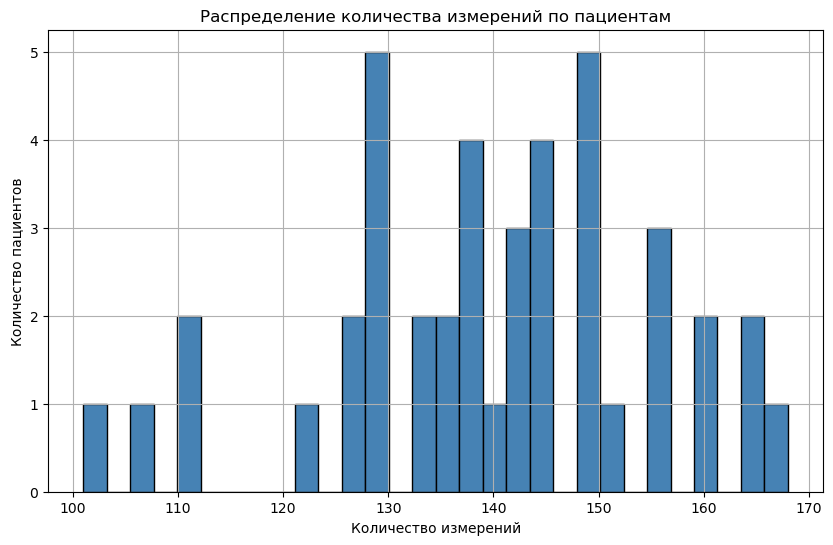

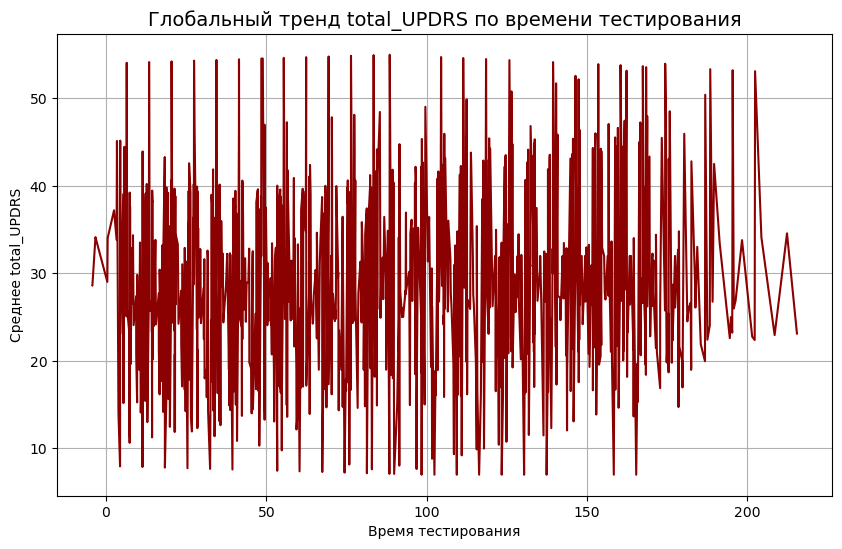

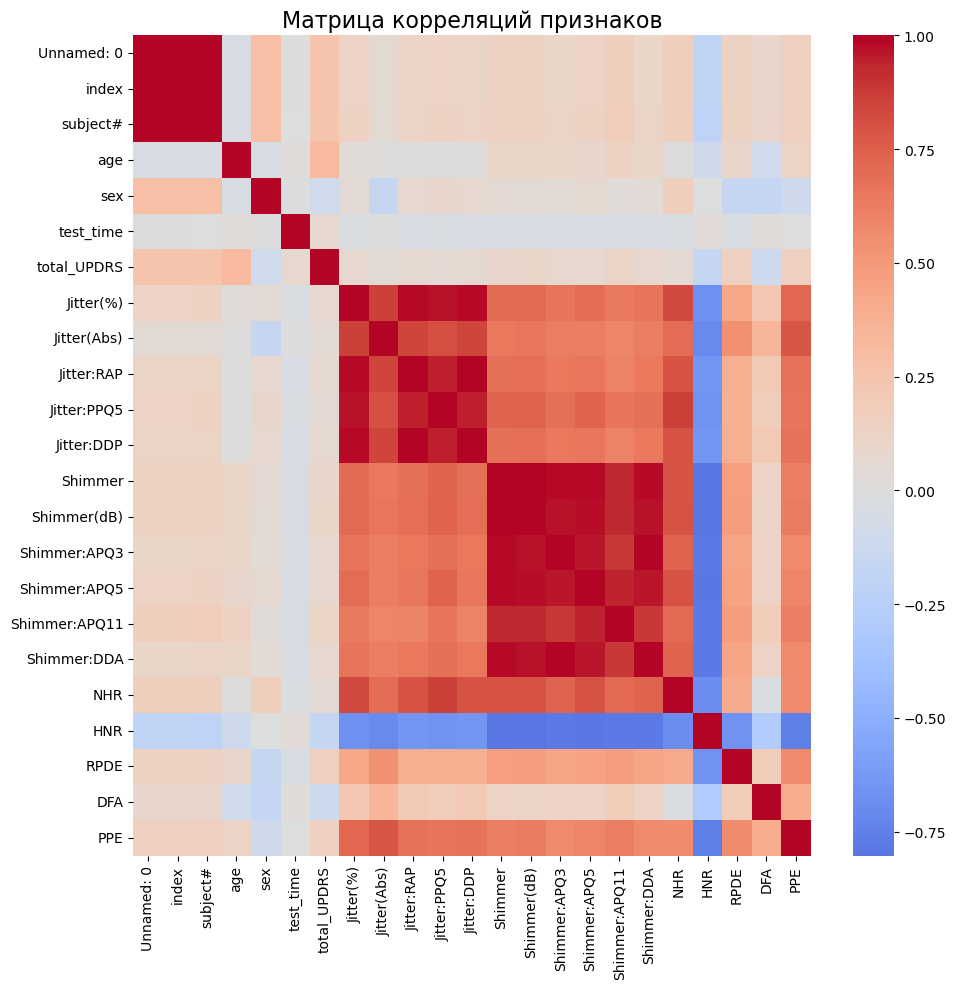


=== Корреляция признаков с total_UPDRS ===
total_UPDRS      1.000000
age              0.310290
subject#         0.253643
Unnamed: 0       0.251196
index            0.251196
RPDE             0.156897
PPE              0.156195
Shimmer:APQ11    0.120838
Shimmer(dB)      0.098790
Shimmer          0.092141
Shimmer:APQ5     0.083467
Shimmer:DDA      0.079363
Shimmer:APQ3     0.079363
test_time        0.075263
Jitter(%)        0.074247
Jitter:DDP       0.064027
Jitter:RAP       0.064015
Jitter:PPQ5      0.063352
NHR              0.060952
Jitter(Abs)      0.054074
sex             -0.096559
DFA             -0.113475
HNR             -0.162117
Name: total_UPDRS, dtype: float64

=== Таблица корреляций пар признаков ===


,Признак 1,Признак 2,Корреляция,Комментарий
0,Unnamed: 0,index,1.000000,⚠️ Возможная избыточность (|корр| > 0.9)
219,Shimmer:APQ3,Shimmer:DDA,1.000000,⚠️ Возможная избыточность (|корр| > 0.9)
163,Jitter:RAP,Jitter:DDP,1.000000,⚠️ Возможная избыточность (|корр| > 0.9)
22,index,subject#,0.999544,⚠️ Возможная избыточность (|корр| > 0.9)
1,Unnamed: 0,subject#,0.999544,⚠️ Возможная избыточность (|корр| > 0.9)
198,Shimmer,Shimmer(dB),0.992334,⚠️ Возможная избыточность (|корр| > 0.9)
200,Shimmer,Shimmer:APQ5,0.984904,⚠️ Возможная избыточность (|корр| > 0.9)
136,Jitter(%),Jitter:DDP,0.984184,⚠️ Возможная избыточность (|корр| > 0.9)
134,Jitter(%),Jitter:RAP,0.984181,⚠️ Возможная избыточность (|корр| > 0.9)
199,Shimmer,Shimmer:APQ3,0.979828,⚠️ Возможная избыточность (|корр| > 0.9)



=== Асимметрия и эксцесс (числовые признаки) ===


,Асимметрия,Эксцесс
Unnamed: 0,0.000000,-1.200000
index,0.000000,-1.200000
subject#,0.002996,-1.249432
age,-0.379037,0.668864
sex,0.782674,-1.387422
test_time,0.077700,-1.147422
total_UPDRS,0.270984,-0.356422
Jitter(%),6.450198,67.438108
Jitter(Abs),3.239836,17.579714
Jitter:RAP,6.943665,78.466738


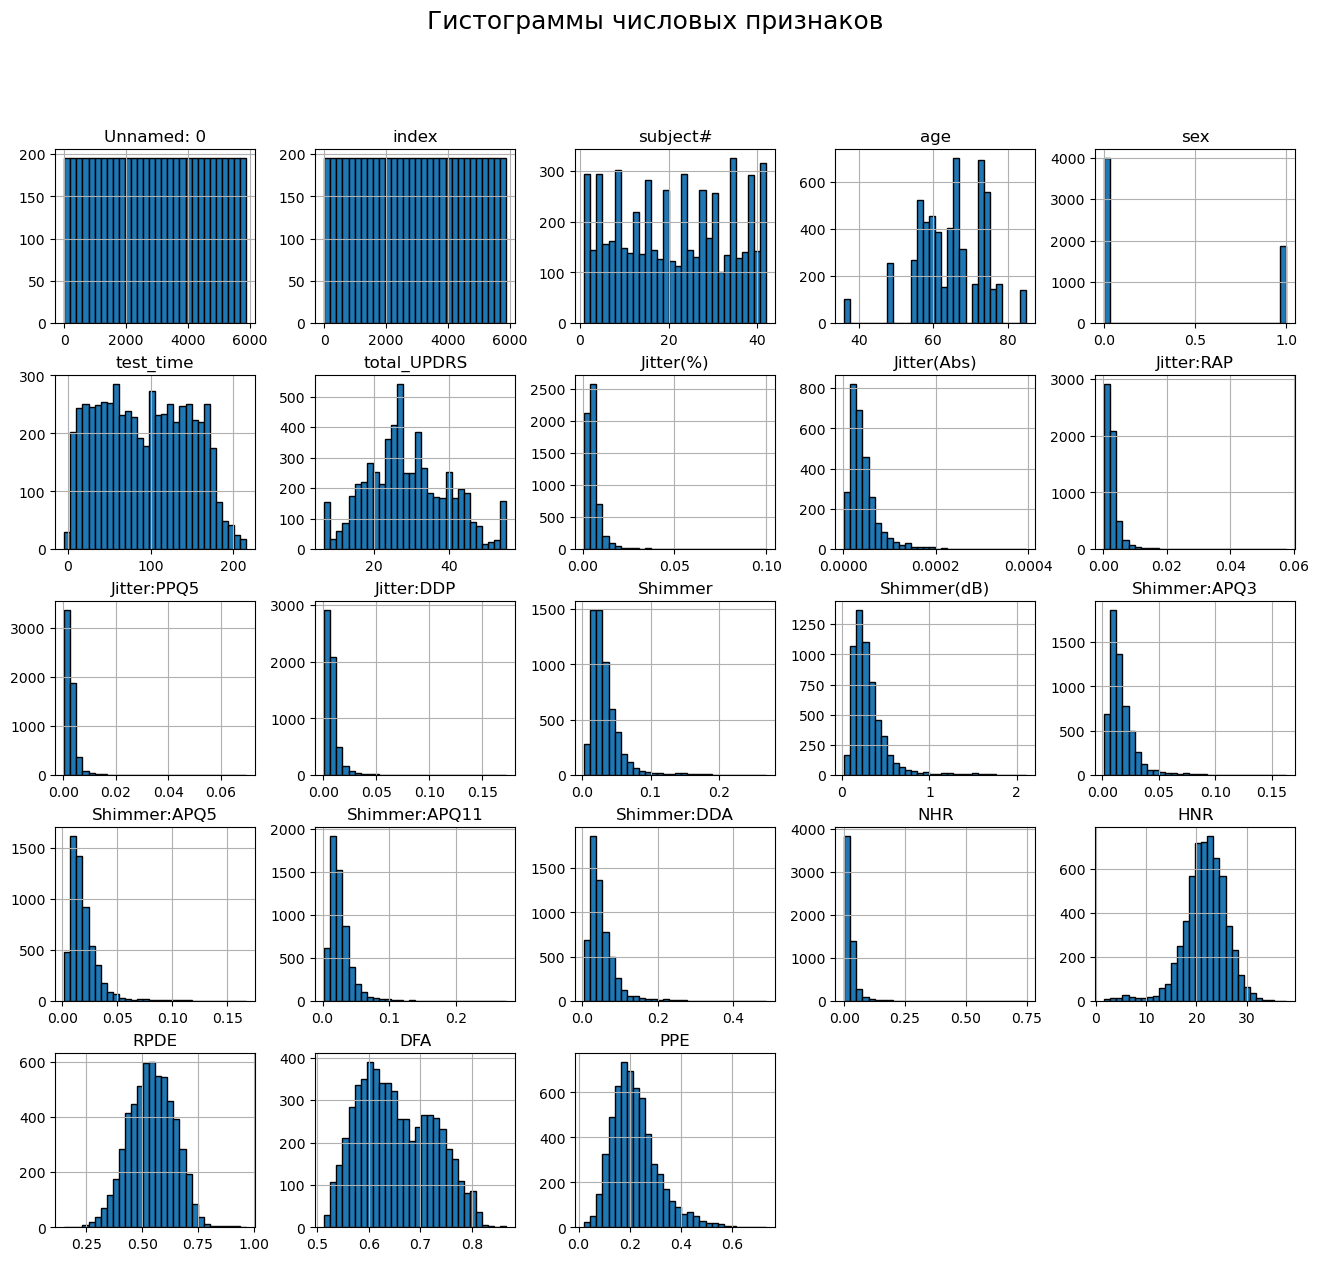

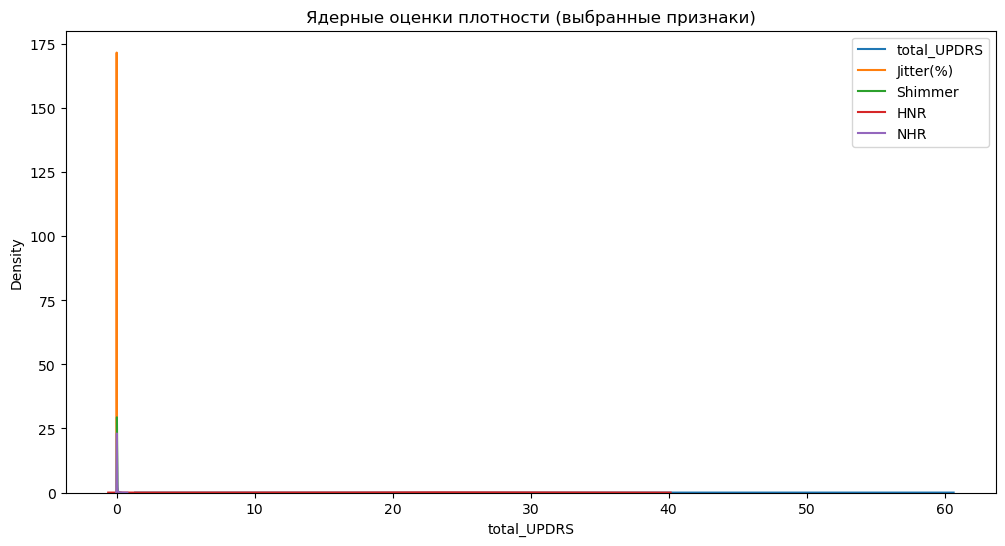


=== Обнаружение выбросов (метод IQR) ===


,Кол-во выбросов
NHR,436
Jitter:PPQ5,425
Jitter:RAP,414
Jitter:DDP,413
Jitter(%),398
Shimmer,333
Shimmer:APQ3,332
Shimmer(dB),332
Shimmer:DDA,331
Shimmer:APQ11,314


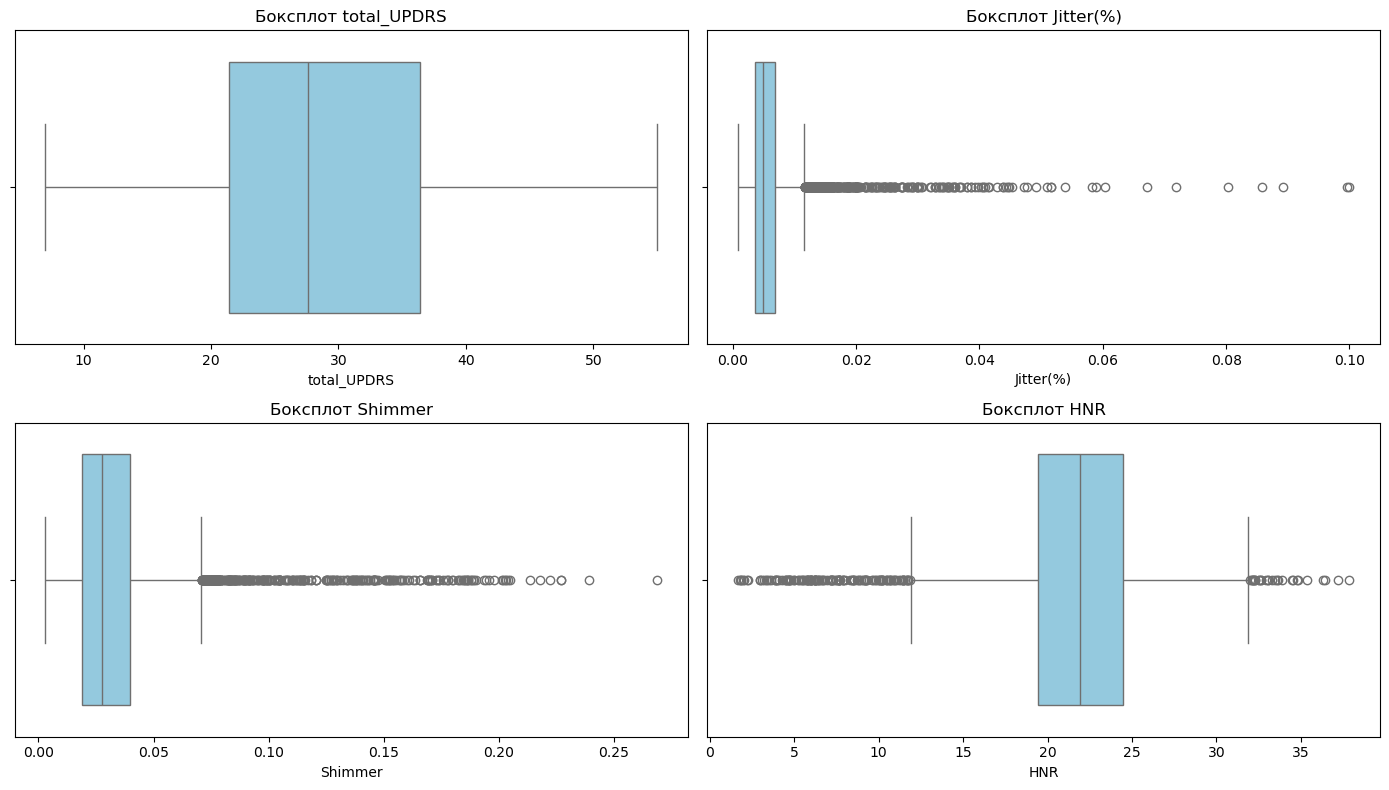

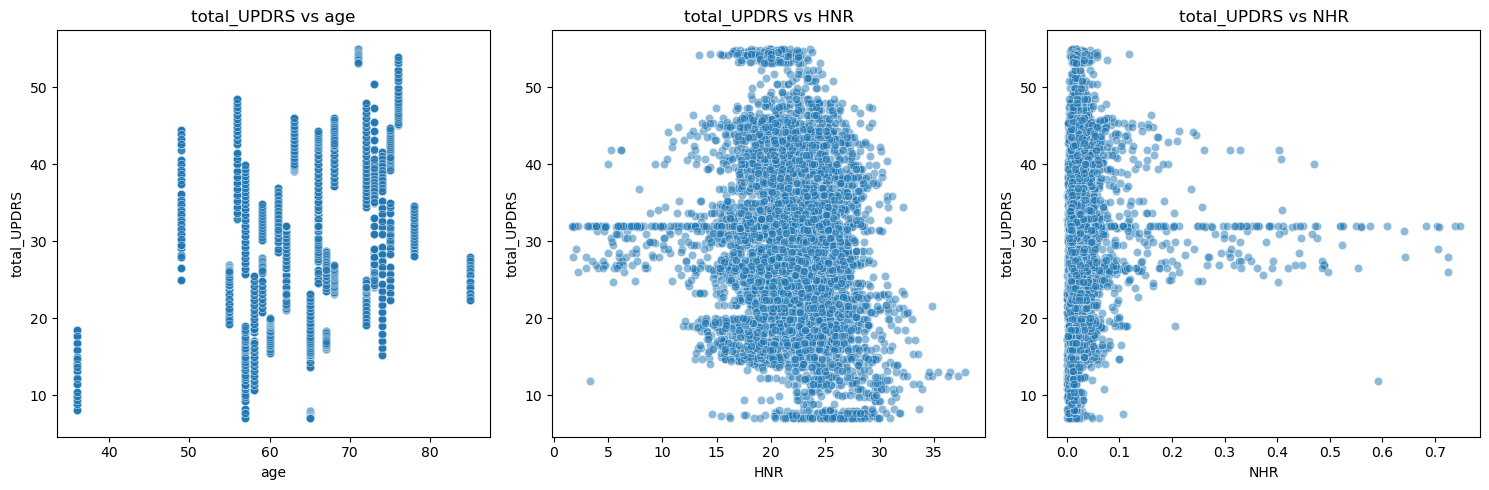

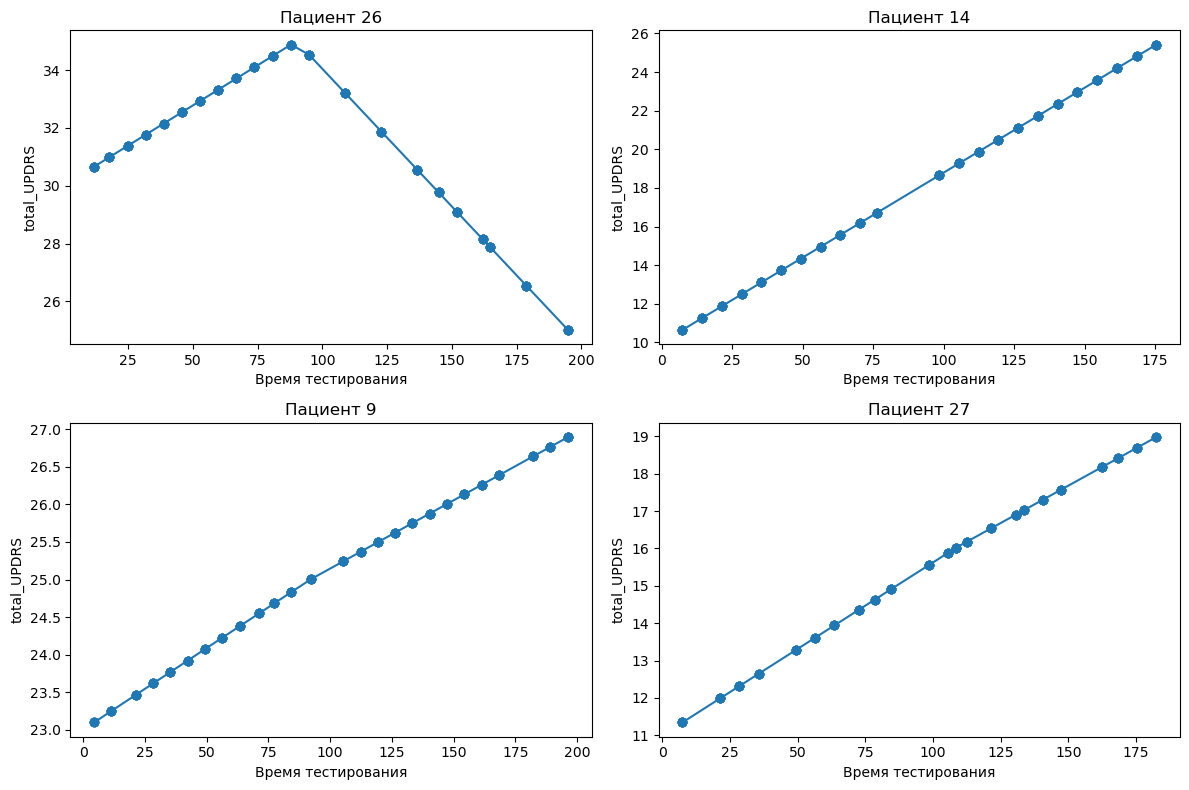

In [ ]:
print(f"Размер: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

print("\nПервые 5 строк:")
display(df.head())
size_mb = os.path.getsize(data_path) / (1024 * 1024)

print("=== Основная информация о наборе данных ===")
print(f"1️⃣ Размер набора данных: {size_mb:.2f} МБ")
print(f"2️⃣ Количество записей: {len(df)}")
print(f"3️⃣ Количество признаков: {len(df.columns)}")
print(f"4️⃣ Целевая переменная: 'total_UPDRS' (тип: {df['total_UPDRS'].dtype})")
print(f"5️⃣ Категориальный признак: 'sex' (бинарный 0/1)")
print(f"6️⃣ Уникальных пациентов: {df['subject#'].nunique()}")
print(f"7️⃣ Временной диапазон тестов: {df['test_time'].min()} → {df['test_time'].max()}")

print("\n=== Пропущенные значения (по колонкам) ===")
print(df.isnull().sum())

print("\n=== Пропущенные значения (по строкам) ===")
print(df.isnull().sum(axis=1).value_counts().sort_index())

print("=== Типы признаков ===")
print(df.dtypes)

# === Удаление motor_UPDRS ===
if 'motor_UPDRS' in df.columns:
    df = df.drop('motor_UPDRS', axis=1)
    print("\n✅ Колонка 'motor_UPDRS' удалена.")

print("=== Описательная статистика набора данных ===")
display(df.describe(include="all"))

# === Статистика по пациентам ===
# Balanced dataset if most patients have similar counts; imbalance could bias models.
subject_counts = df['subject#'].value_counts()
print("\n=== Количество измерений по пациентам ===")
print(f"Среднее на пациента: {subject_counts.mean():.2f}")
print(f"Мин на пациента: {subject_counts.min()}, Макс на пациента: {subject_counts.max()}")

plt.figure(figsize=(10,6))
subject_counts.hist(bins=30, color="steelblue", edgecolor="black")
plt.title("Распределение количества измерений по пациентам")
plt.xlabel("Количество измерений")
plt.ylabel("Количество пациентов")
plt.show()
print("")

# === Глобальный тренд total_UPDRS по времени ===
# Tells you whether time is a strong predictor
plt.figure(figsize=(10,6))
df_grouped = df.groupby("test_time")["total_UPDRS"].mean()
plt.plot(df_grouped.index, df_grouped.values, color="darkred")
plt.title("Глобальный тренд total_UPDRS по времени тестирования", fontsize=14)
plt.xlabel("Время тестирования")
plt.ylabel("Среднее total_UPDRS")
plt.grid(True)
plt.show()

print("")

# === Анализ корреляций ===
# Features highly correlated with total_UPDRS are potential predictors.
# Features highly correlated with each other may be redundant.
# Helps with feature selection and avoiding multicollinearity.
corr_matrix = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['total_UPDRS'].sort_values(ascending=False)
print("\n=== Корреляция признаков с total_UPDRS ===")
print(target_corr)

# === Сильно коррелирующие пары признаков (с комментариями) ===
high_corr_records = []

for i, col1 in enumerate(corr_matrix.columns):
    for j, col2 in enumerate(corr_matrix.columns):
        if i < j:  # избегаем дубликатов и самокорреляции
            corr_val = corr_matrix.loc[col1, col2]
            comment = (
                "⚠️ Возможная избыточность (|корр| > 0.9)"
                if abs(corr_val) > 0.9
                else "Проблем избыточности нет"
            )
            high_corr_records.append((col1, col2, corr_val, comment))

# Конвертируем в DataFrame для красивого отображения
high_corr_df = pd.DataFrame(
    high_corr_records,
    columns=["Признак 1", "Признак 2", "Корреляция", "Комментарий"]
).sort_values(by="Корреляция", key=lambda x: abs(x), ascending=False)

print("\n=== Таблица корреляций пар признаков ===")
display(high_corr_df.head(20))  # показываем топ-20 самых сильных корреляций

# === Анализ распределений и асимметрии ===
numeric_features = df.select_dtypes(include=[np.number]).columns
print("\n=== Асимметрия и эксцесс (числовые признаки) ===")
skew_kurt = pd.DataFrame({
    "Асимметрия": df[numeric_features].apply(lambda x: skew(x.dropna())),
    "Эксцесс": df[numeric_features].apply(lambda x: kurtosis(x.dropna()))
})
display(skew_kurt)

df[numeric_features].hist(figsize=(16, 14), bins=30, edgecolor="black")
plt.suptitle("Гистограммы числовых признаков", fontsize=18)
plt.show()

plt.figure(figsize=(12, 6))
for col in ['total_UPDRS', 'Jitter(%)', 'Shimmer', 'HNR', 'NHR']:
    sns.kdeplot(df[col].dropna(), label=col)
plt.title("Ядерные оценки плотности (выбранные признаки)")
plt.legend()
plt.show()

# === Обнаружение выбросов методом IQR ===
print("\n=== Обнаружение выбросов (метод IQR) ===")
outlier_summary = {}
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Кол-во выбросов"])
display(outlier_df.sort_values("Кол-во выбросов", ascending=False).head(10))

plt.figure(figsize=(14, 8))
for i, col in enumerate(['total_UPDRS', 'Jitter(%)', 'Shimmer', 'HNR']):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Боксплот {col}")
plt.tight_layout()
plt.show()

# === Диаграммы рассеяния: целевая переменная vs выбранные признаки ===
top_features = ['age', 'HNR', 'NHR']
plt.figure(figsize=(15, 5))
for i, feat in enumerate(top_features):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=df[feat], y=df['total_UPDRS'], alpha=0.5)
    plt.title(f'total_UPDRS vs {feat}')
plt.tight_layout()
plt.show()

# === Временные тренды для нескольких пациентов ===
subject_sample = np.random.choice(df['subject#'].unique(), 4, replace=False)
plt.figure(figsize=(12, 8))
for i, subject in enumerate(subject_sample):
    subject_data = df[df['subject#'] == subject].sort_values('test_time')
    plt.subplot(2, 2, i+1)
    plt.plot(subject_data['test_time'], subject_data['total_UPDRS'], marker='o', linestyle='-')
    plt.title(f'Пациент {subject}', fontsize=12)
    plt.xlabel('Время тестирования')
    plt.ylabel('total_UPDRS')
plt.tight_layout()
plt.show()

Разведочный анализ данных выявил несколько ключевых особенностей. Набор данных хорошо сбалансирован между пациентами, со средним показателем ~140 измерений на субъекта, что гарантирует отсутствие доминирования какого-либо отдельного пациента. Целевая переменная total_UPDRS демонстрирует умеренную корреляцию с возрастом и слабые, но клинически значимые связи с акустическими характеристиками, такими как HNR (отрицательная) и NHR (положительная). 

Между семействами признаков jitter и shimmer наблюдается сильная мультиколлинеарность, указывающая на избыточность, которую следует устранить путём отбора признаков или снижения размерности. Анализ распределений выявляет значительную асимметрию и экстремальный эксцесс в показателях jitter, shimmer и NHR, с сотнями выбросов, что подтверждает необходимость robust препроцессинга, включая масштабирование, преобразования или обработку выбросов.

Временные тренды показывают гетерогенные нелинейные траектории пациентов, что оправдывает использование рекуррентных моделей, таких как двунаправленная LSTM, вместе с базовыми полносвязными сетями. В целом, эффективные алгоритмы должны сочетать тщательный препроцессинг, сокращение избыточности и временное моделирование для захвата как стабильных предикторов, так и индивидуальной вариабельности пациентов.

# Data Preparation

In [24]:
# =============================================================================
# B. ПОДГОТОВКА ДАННЫХ
# =============================================================================

print("=" * 80)
print("B. ПОДГОТОВКА ДАННЫХ")
print("=" * 80)

# Создаем копию данных для обработки
df_processed = df.copy()

# B.1 Удаление столбцов по условию задания
print("\nB.1 УДАЛЕНИЕ СТОЛБЦОВ")
print("-" * 40)

# Удаляем motor_UPDRS по варианту
if 'motor_UPDRS' in df_processed.columns:
    df_processed = df_processed.drop('motor_UPDRS', axis=1)
    print("✅ Удален столбец 'motor_UPDRS' по условию варианта")

# B.2 Обработка пропущенных значений (KNNImputer - будет применен после разделения)
print("\nB.2 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")
print("-" * 40)

missing_before = df_processed.isnull().sum().sum()
print(f"Общее количество пропущенных значений: {missing_before}")

if missing_before > 0:
    missing_cols = df_processed.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]
    print("Столбцы с пропущенными значениями:")
    for col, count in missing_cols.items():
        print(f"  {col}: {count} пропусков ({count/len(df_processed)*100:.1f}%)")

# B.3 Обработка выбросов (Winsorize)
print("\nB.3 ОБРАБОТКА ВЫБРОСОВ (WINSORIZE)")
print("-" * 40)

# Определяем признаки для обработки выбросов
outlier_features = ['Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 
                   'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 
                   'Shimmer:DDA', 'NHR']

# Применяем winsorization к указанным признакам
for feature in outlier_features:
    if feature in df_processed.columns:
        original_skew = df_processed[feature].skew()
        # Winsorize верхние и нижние 2%
        df_processed[feature] = winsorize(df_processed[feature], limits=[0.02, 0.02])
        new_skew = df_processed[feature].skew()
        print(f"  {feature}: асимметрия {original_skew:.2f} → {new_skew:.2f}")

print("✅ Winsorization применен к jitter, shimmer и NHR признакам")

# B.4 Удаление идентификационных столбцов (MODIFIED - keep subject# for now)
print("\nB.4 УДАЛЕНИЕ ИДЕНТИФИКАЦИОННЫХ СТОЛБЦОВ")
print("-" * 40)

# Keep subject# for now, we'll remove it after splitting
id_columns = ['index']  # Remove subject# from this list for now
df_features = df_processed.drop(columns=id_columns, errors='ignore')
print(f"✅ Удалены идентификационные столбцы: {id_columns}")
print(f"Размер датасета: {df_features.shape}")

# B.5 Отбор признаков
print("\nB.5 ОТБОР ПРИЗНАКОВ")
print("-" * 40)

# B.5.1 Удаление высококоррелированных признаков (|corr| > 0.9)
print("B.5.1 УДАЛЕНИЕ ВЫСОКОКОРРЕЛИРОВАННЫХ ПРИЗНАКОВ")

# Создаем временную копию без целевой переменной для анализа корреляций
X_temp = df_features.drop('total_UPDRS', axis=1)
corr_matrix = X_temp.corr().abs()

# Находим высококоррелированные пары
high_corr_features = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
            high_corr_features.add(col2)  # Удаляем второй признак из пары
            print(f"  Высокая корреляция: {col1} - {col2}: {corr_matrix.iloc[i, j]:.3f}")

# Удаляем высококоррелированные признаки
if high_corr_features:
    df_low_corr = df_features.drop(columns=high_corr_features)
    print(f"✅ Удалены высококоррелированные признаки: {list(high_corr_features)}")
else:
    df_low_corr = df_features.copy()
    print("✅ Высококоррелированных признаков не обнаружено")

print(f"Размер после удаления коррелированных признаков: {df_low_corr.shape}")

# B.5.2 SelectKBest для отбора признаков
print("\nB.5.2 SELECTKBEST ОТБОР ПРИЗНАКОВ")

X = df_low_corr.drop('total_UPDRS', axis=1)
y = df_low_corr['total_UPDRS']

# Выбираем 15 лучших признаков
k_best = min(15, X.shape[1])
selector = SelectKBest(score_func=f_regression, k=k_best)
X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()].tolist()
selected_scores = selector.scores_[selector.get_support()]

print(f"✅ Отобрано {len(selected_features)} наиболее значимых признаков:")
for feat, score in zip(selected_features, selected_scores):
    print(f"  {feat}: {score:.2f}")

# Создаем датасет с отобранными признаками
df_selected = df_low_corr[selected_features + ['total_UPDRS']].copy()
print(f"Размер датасета с отобранными признаками: {df_selected.shape}")

# B.6 Обработка категориальных признаков
print("\nB.6 ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("-" * 40)

# Проверяем и обрабатываем признак 'sex'
if 'sex' in df_features.columns:
    if df_features['sex'].dtype == 'object':
        # Преобразуем в бинарный числовой формат
        df_features['sex'] = df_features['sex'].astype('category').cat.codes
        df_low_corr['sex'] = df_low_corr['sex'].astype('category').cat.codes
        df_selected['sex'] = df_selected['sex'].astype('category').cat.codes
        print("✅ Признак 'sex' преобразован в бинарный числовой формат")
    else:
        print("✅ Признак 'sex' уже в числовом формате 0/1")
else:
    print("ℹ️ Признак 'sex' не найден в датасете")

# B.7 Разделение на обучающую, валидационную и тестовую выборки
print("\nB.7 РАЗДЕЛЕНИЕ НА ВЫБОРКИ")
print("-" * 40)

def create_train_val_test_splits(df, test_size=0.2, val_size=0.2, random_state=42):
    """Создает разделенные выборки с сохранением индексов"""
    X = df.drop('total_UPDRS', axis=1)
    y = df['total_UPDRS']
    
    # Первое разделение: временная и тестовая
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=True
    )
    
    # Второе разделение: обучающая и валидационная
    val_relative_size = val_size / (1 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_relative_size, random_state=random_state, shuffle=True
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Создаем разделенные выборки для двух основных датасетов
print("Создание разделенных выборок...")

# Для датасета со всеми признаками (после удаления коррелированных)
X_train_full, X_val_full, X_test_full, y_train_full, y_val_full, y_test_full = create_train_val_test_splits(df_low_corr)

# Для датасета с отобранными признаками
X_train_sel, X_val_sel, X_test_sel, y_train_sel, y_val_sel, y_test_sel = create_train_val_test_splits(df_selected)

print("✅ Разделенные выборки созданы:")
print(f"  Полный датасет: train={X_train_full.shape[0]}, val={X_val_full.shape[0]}, test={X_test_full.shape[0]}")
print(f"  Отобранные признаки: train={X_train_sel.shape[0]}, val={X_val_sel.shape[0]}, test={X_test_sel.shape[0]}")

# B.7.2 УДАЛЕНИЕ SUBJECT# ПОСЛЕ РАЗДЕЛЕНИЯ (NEW SECTION)
print("\nB.7.2 УДАЛЕНИЕ SUBJECT# ПОСЛЕ РАЗДЕЛЕНИЯ")
print("-" * 40)

# Remove subject# from all splits to prevent data leakage
X_train_full = X_train_full.drop('subject#', axis=1, errors='ignore')
X_val_full = X_val_full.drop('subject#', axis=1, errors='ignore')
X_test_full = X_test_full.drop('subject#', axis=1, errors='ignore')

X_train_sel = X_train_sel.drop('subject#', axis=1, errors='ignore')
X_val_sel = X_val_sel.drop('subject#', axis=1, errors='ignore')
X_test_sel = X_test_sel.drop('subject#', axis=1, errors='ignore')

print("✅ Subject# removed from all splits to prevent data leakage")

# B.8 Применение KNNImputer (только на обучающих данных)
print("\nB.8 ПРИМЕНЕНИЕ KNNIMPUTER")
print("-" * 40)

def apply_knn_imputation(X_train, X_val, X_test, n_neighbors=5):
    """Применяет KNN импутацию отдельно к каждой выборке"""
    # Проверяем наличие пропущенных значений
    if X_train.isnull().sum().sum() == 0:
        return X_train, X_val, X_test, None
    
    knn_imputer = KNNImputer(n_neighbors=n_neighbors)
    
    # Fit и transform на обучающих данных
    X_train_imputed = knn_imputer.fit_transform(X_train)
    X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
    
    # Transform на валидационных и тестовых данных
    X_val_imputed = knn_imputer.transform(X_val)
    X_val_imputed = pd.DataFrame(X_val_imputed, columns=X_val.columns, index=X_val.index)
    
    X_test_imputed = knn_imputer.transform(X_test)
    X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)
    
    print(f"✅ KNN импутация применена (n_neighbors={n_neighbors})")
    return X_train_imputed, X_val_imputed, X_test_imputed, knn_imputer

# Применяем KNN импутацию к обеим версиям датасетов
X_train_full_imp, X_val_full_imp, X_test_full_imp, knn_imputer_full = apply_knn_imputation(X_train_full, X_val_full, X_test_full)
X_train_sel_imp, X_val_sel_imp, X_test_sel_imp, knn_imputer_sel = apply_knn_imputation(X_train_sel, X_val_sel, X_test_sel)

# B.9 Стандартизация данных (StandardScaler) - CORRECTED VERSION
print("\nB.9 СТАНДАРТИЗАЦИЯ ДАННЫХ (STANDARDSCALER)")
print("-" * 40)

def apply_standard_scaling(X_train, X_val, X_test):
    """Применяет стандартизацию - fit на обучающих данных, transform на всех"""
    scaler = StandardScaler()
    
    # Fit ТОЛЬКО на обучающих данных
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    
    # Transform на валидационных и тестовых данных (используя параметры с train)
    X_val_scaled = scaler.transform(X_val)
    X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
    
    X_test_scaled = scaler.transform(X_test)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

print("Применение стандартизации к 4 вариантам датасетов...")

# Создаем 4 окончательных варианта датасетов как требуется:

# 1. Исходный набор (полные признаки) без стандартизации
dataset1 = {
    'X_train': X_train_full_imp,
    'X_val': X_val_full_imp, 
    'X_test': X_test_full_imp,
    'y_train': y_train_full,
    'y_val': y_val_full,
    'y_test': y_test_full,
    'name': 'Исходный набор (полные признаки)',
    'features': X_train_full_imp.columns.tolist()
}

# 2. Преобразованный исходный набор (полные признаки + стандартизация)
X_train_full_std, X_val_full_std, X_test_full_std, scaler_full = apply_standard_scaling(
    X_train_full_imp, X_val_full_imp, X_test_full_imp
)
dataset2 = {
    'X_train': X_train_full_std,
    'X_val': X_val_full_std,
    'X_test': X_test_full_std, 
    'y_train': y_train_full,
    'y_val': y_val_full,
    'y_test': y_test_full,
    'name': 'Преобразованный исходный набор (стандартизация)',
    'features': X_train_full_std.columns.tolist(),
    'scaler': scaler_full
}

# 3. Построенный набор (отобранные признаки) без стандартизации
dataset3 = {
    'X_train': X_train_sel_imp,
    'X_val': X_val_sel_imp,
    'X_test': X_test_sel_imp,
    'y_train': y_train_sel,
    'y_val': y_val_sel, 
    'y_test': y_test_sel,
    'name': 'Построенный набор (отобранные признаки)',
    'features': X_train_sel_imp.columns.tolist()
}

# 4. Преобразованный построенный набор (отобранные признаки + стандартизация)
X_train_sel_std, X_val_sel_std, X_test_sel_std, scaler_sel = apply_standard_scaling(
    X_train_sel_imp, X_val_sel_imp, X_test_sel_imp
)
dataset4 = {
    'X_train': X_train_sel_std,
    'X_val': X_val_sel_std,
    'X_test': X_test_sel_std,
    'y_train': y_train_sel,
    'y_val': y_val_sel,
    'y_test': y_test_sel, 
    'name': 'Преобразованный построенный набор (стандартизация)',
    'features': X_train_sel_std.columns.tolist(),
    'scaler': scaler_sel
}

# Сохраняем все датасеты в словарь
datasets = {
    'original': dataset1,
    'original_std': dataset2, 
    'selected': dataset3,
    'selected_std': dataset4
}

print("✅ Созданы 4 варианта датасетов для моделирования:")
for key, dataset in datasets.items():
    print(f"  {key}: {dataset['name']} - {len(dataset['features'])} признаков")

# B.10 Финальная подготовка для нейросетевых моделей
print("\nB.10 ПОДГОТОВКА ДЛЯ НЕЙРОСЕТЕВЫХ МОДЕЛЕЙ")
print("-" * 40)

# Преобразуем данные в numpy arrays для TensorFlow
for key in datasets.keys():
    dataset = datasets[key]
    
    # Преобразуем в numpy arrays
    dataset['X_train_array'] = dataset['X_train'].values.astype('float32')
    dataset['X_val_array'] = dataset['X_val'].values.astype('float32') 
    dataset['X_test_array'] = dataset['X_test'].values.astype('float32')
    dataset['y_train_array'] = dataset['y_train'].values.astype('float32')
    dataset['y_val_array'] = dataset['y_val'].values.astype('float32')
    dataset['y_test_array'] = dataset['y_test'].values.astype('float32')
    
    print(f"  {key}: arrays prepared - {dataset['X_train_array'].shape}")

# B.11 LSTM SEQUENCE PREPARATION (CORRECTED VERSION)
print("\nB.11 ПОДГОТОВКА ПОСЛЕДОВАТЕЛЬНОСТЕЙ ДЛЯ LSTM")
print("-" * 40)

def create_sliding_windows(X, y, sequence_length=30):
    """Создает скользящие окна из данных для LSTM"""
    sequences = []
    targets = []
    
    for i in range(len(X) - sequence_length + 1):
        sequences.append(X[i:(i + sequence_length)])
        targets.append(y[i + sequence_length - 1])  # Target aligned with last timestep
    
    return np.array(sequences), np.array(targets)

def prepare_lstm_sequences(datasets_dict, sequence_length=30):
    """Подготавливает последовательности для LSTM из всех датасетов"""
    lstm_datasets = {}
    
    for key, dataset in datasets_dict.items():
        print(f"Preparing LSTM sequences for {key}...")
        
        # Create sequences from existing splits
        X_train_seq, y_train_seq = create_sliding_windows(
            dataset['X_train_array'], dataset['y_train_array'], sequence_length
        )
        X_val_seq, y_val_seq = create_sliding_windows(
            dataset['X_val_array'], dataset['y_val_array'], sequence_length
        )
        X_test_seq, y_test_seq = create_sliding_windows(
            dataset['X_test_array'], dataset['y_test_array'], sequence_length
        )
        
        lstm_datasets[key] = {
            'X_train_seq': X_train_seq, 'y_train_seq': y_train_seq,
            'X_val_seq': X_val_seq, 'y_val_seq': y_val_seq,
            'X_test_seq': X_test_seq, 'y_test_seq': y_test_seq,
            'sequence_length': sequence_length,
            'name': dataset['name'] + ' (LSTM sequences)',
            'features': dataset['features']
        }
        
        print(f"  {key}: {X_train_seq.shape} sequences")
    
    return lstm_datasets

# Prepare LSTM sequences for all dataset variants
print("Preparing LSTM sequences for bidirectional LSTM...")
lstm_datasets = prepare_lstm_sequences(datasets, sequence_length=20)

# Add LSTM datasets to main dictionary
for key in lstm_datasets.keys():
    datasets[f'{key}_lstm'] = lstm_datasets[key]

print("✅ LSTM sequences prepared for bidirectional LSTM model")

print("\n" + "=" * 80)
print("✅ ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА!")
print("✅ Данные готовы для этапа 'ОЦЕНКА МОДЕЛЕЙ'")
print("✅ Созданы 4 варианта датасетов как требуется по заданию")
print("✅ Подготовлены последовательности для двунаправленной LSTM")
print("=" * 80)

# Данные готовы для использования в следующем этапе
# Переменная 'datasets' содержит все подготовленные данные

# B.12 ИНСПЕКЦИЯ ДАННЫХ ПОСЛЕ ПРЕДОБРАБОТКИ
print("\nB.12 ИНСПЕКЦИЯ ДАННЫХ ПОСЛЕ ПРЕДОБРАБОТКИ")
print("-" * 40)

print("📊 ОБЗОР ПОДГОТОВЛЕННЫХ ДАТАСЕТОВ:")
print("=" * 50)

for key, dataset in datasets.items():
    if 'lstm' not in key:  # Skip LSTM datasets for now
        print(f"\n🔹 {dataset['name']}:")
        print(f"   Размеры: X_train {dataset['X_train_array'].shape}, "
              f"X_val {dataset['X_val_array'].shape}, "
              f"X_test {dataset['X_test_array'].shape}")
        print(f"   Признаки: {len(dataset['features'])}")
        print(f"   Диапазон целевой переменной: "
              f"{dataset['y_train_array'].min():.2f} - {dataset['y_train_array'].max():.2f}")

# Проверка распределения целевой переменной
print("\n📈 РАСПРЕДЕЛЕНИЕ TARGET (total_UPDRS) ПО ВЫБОРКАМ:")
print("=" * 50)

for key, dataset in datasets.items():
    if 'lstm' not in key:
        print(f"\n{dataset['name']}:")
        train_stats = {
            'mean': np.mean(dataset['y_train_array']),
            'std': np.std(dataset['y_train_array']),
            'min': np.min(dataset['y_train_array']),
            'max': np.max(dataset['y_train_array'])
        }
        val_stats = {
            'mean': np.mean(dataset['y_val_array']),
            'std': np.std(dataset['y_val_array']),
            'min': np.min(dataset['y_val_array']),
            'max': np.max(dataset['y_val_array'])
        }
        print(f"  Train: μ={train_stats['mean']:.2f}, σ={train_stats['std']:.2f}, "
              f"range={train_stats['min']:.2f}-{train_stats['max']:.2f}")
        print(f"  Val:   μ={val_stats['mean']:.2f}, σ={val_stats['std']:.2f}, "
              f"range={val_stats['min']:.2f}-{val_stats['max']:.2f}")

# Проверка стандартизированных данных
print("\n🔍 ПРОВЕРКА СТАНДАРТИЗАЦИИ:")
print("=" * 50)

for key in ['original_std', 'selected_std']:
    if key in datasets:
        dataset = datasets[key]
        print(f"\n{dataset['name']}:")
        # Проверяем, что среднее близко к 0, а std к 1
        train_mean = np.mean(dataset['X_train_array'], axis=0)
        train_std = np.std(dataset['X_train_array'], axis=0)
        
        print(f"  Train - Среднее признаков: {np.mean(train_mean):.4f} ± {np.std(train_mean):.4f}")
        print(f"  Train - Std признаков: {np.mean(train_std):.4f} ± {np.std(train_std):.4f}")

# Проверка LSTM последовательностей
print("\n🔄 ИНСПЕКЦИЯ LSTM ПОСЛЕДОВАТЕЛЬНОСТЕЙ:")
print("=" * 50)

lstm_keys = [key for key in datasets.keys() if 'lstm' in key]
for key in lstm_keys:
    dataset = datasets[key]
    print(f"\n{dataset['name']}:")
    print(f"  Форма последовательностей: {dataset['X_train_seq'].shape}")
    print(f"  Длина последовательности: {dataset['sequence_length']}")
    print(f"  Размерность признаков: {dataset['X_train_seq'].shape[-1]}")
    print(f"  Количество последовательностей: {dataset['X_train_seq'].shape[0]}")

# Проверка на наличие NaN значений
print("\n🔎 ПРОВЕРКА НА ОТСУТСТВИЕ NaN:")
print("=" * 50)

all_clean = True
for key, dataset in datasets.items():
    if 'lstm' in key:
        arrays_to_check = ['X_train_seq', 'y_train_seq', 'X_val_seq', 'y_val_seq', 'X_test_seq', 'y_test_seq']
    else:
        arrays_to_check = ['X_train_array', 'y_train_array', 'X_val_array', 'y_val_array', 'X_test_array', 'y_test_array']
    
    for array_name in arrays_to_check:
        if array_name in dataset:
            if np.isnan(dataset[array_name]).any():
                print(f"❌ В {key}.{array_name} обнаружены NaN значения!")
                all_clean = False

if all_clean:
    print("✅ Все данные очищены от NaN значений")

# Сводка по всем датасетам
print("\n📋 СВОДКА ПО ВСЕМ ДАТАСЕТАМ:")
print("=" * 50)

print(f"Всего подготовлено датасетов: {len(datasets)}")
print("\nТипы датасетов:")
for key in datasets.keys():
    if 'lstm' in key:
        print(f"  🧠 {key}: LSTM последовательности")
    else:
        print(f"  📊 {key}: Стандартные данные")

print("\nГотовы для следующих моделей:")
print("  • Полносвязные нейронные сети: original, original_std, selected, selected_std")
print("  • Двунаправленная LSTM: все датасеты с суффиксом _lstm")

print("\n" + "=" * 80)
print("🔍 ИНСПЕКЦИЯ ДАННЫХ ЗАВЕРШЕНА!")
print("✅ Все данные проверены и готовы для моделирования")
print("=" * 80)

B. ПОДГОТОВКА ДАННЫХ

B.1 УДАЛЕНИЕ СТОЛБЦОВ
----------------------------------------

B.2 АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
----------------------------------------
Общее количество пропущенных значений: 2931
Столбцы с пропущенными значениями:
  Jitter(Abs): 2931 пропусков (49.9%)

B.3 ОБРАБОТКА ВЫБРОСОВ (WINSORIZE)
----------------------------------------
  Jitter(%): асимметрия 6.45 → 2.28
  Jitter(Abs): асимметрия 3.24 → 3.27
  Jitter:RAP: асимметрия 6.95 → 2.32
  Jitter:PPQ5: асимметрия 7.59 → 2.43
  Jitter:DDP: асимметрия 6.95 → 2.31
  Shimmer: асимметрия 3.31 → 2.21
  Shimmer(dB): асимметрия 3.10 → 2.21
  Shimmer:APQ3: асимметрия 3.10 → 1.89
  Shimmer:APQ5: асимметрия 3.70 → 2.20
  Shimmer:APQ11: асимметрия 3.41 → 1.92
  Shimmer:DDA: асимметрия 3.10 → 1.89
  NHR: асимметрия 6.55 → 3.50
✅ Winsorization применен к jitter, shimmer и NHR признакам

B.4 УДАЛЕНИЕ ИДЕНТИФИКАЦИОННЫХ СТОЛБЦОВ
----------------------------------------
✅ Удалены идентификационные столбцы: ['index']
Размер датасета

In [25]:
# =============================================================================
# C. ОЦЕНКА МОДЕЛЕЙ
# =============================================================================

print("=" * 80)
print("C. ОЦЕНКА МОДЕЛЕЙ")
print("=" * 80)

# C.1 СОЗДАНИЕ И ОБУЧЕНИЕ ПОЛНОСВЯЗНОЙ НЕЙРОННОЙ СЕТИ
print("\nC.1 ПОЛНОСВЯЗНАЯ НЕЙРОННАЯ СЕТЬ (MLP)")
print("-" * 40)

def create_mlp_model(input_dim, learning_rate=0.001):
    """Создает полносвязную нейронную сеть для регрессии"""
    model = tf.keras.Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        Dropout(0.2),
        
        Dense(1, activation='linear')  # Регрессия для total_UPDRS
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', 'mse']
    )
    
    return model

# C.2 СОЗДАНИЕ ДВУНАПРАВЛЕННОЙ LSTM СЕТИ
print("\nC.2 ДВУНАПРАВЛЕННАЯ LSTM СЕТЬ")
print("-" * 40)

def create_bidirectional_lstm_model(sequence_length, n_features, learning_rate=0.001):
    """Создает двунаправленную LSTM сеть для временных последовательностей"""
    model = tf.keras.Sequential([
        Input(shape=(sequence_length, n_features)),
        Masking(mask_value=0.0),
        
        Bidirectional(LSTM(64, return_sequences=True, dropout=0.2)),
        BatchNormalization(),
        
        Bidirectional(LSTM(32, dropout=0.2)),
        BatchNormalization(),
        
        Dense(32, activation='relu'),
        Dropout(0.3),
        
        Dense(16, activation='relu'),
        Dropout(0.2),
        
        Dense(1, activation='linear')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', 'mse']
    )
    
    return model

# C.3 ФУНКЦИИ ДЛЯ ОЦЕНКИ МОДЕЛЕЙ
print("\nC.3 ФУНКЦИИ ОЦЕНКИ КАЧЕСТВА")
print("-" * 40)

def calculate_metrics(y_true, y_pred):
    """Вычисляет метрики качества для регрессии"""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    return {
        'RMSE': rmse,
        'R2': r2,
        'MSE': mse,
        'MAE': mae
    }

def evaluate_model_on_datasets(model, datasets, model_type='mlp'):
    """Оценивает модель на всех датасетах"""
    results = {}
    
    for key, dataset in datasets.items():
        if model_type == 'mlp' and 'lstm' not in key:
            # Для полносвязной сети используем стандартные данные
            X_train, X_val, X_test = dataset['X_train_array'], dataset['X_val_array'], dataset['X_test_array']
            y_train, y_val, y_test = dataset['y_train_array'], dataset['y_val_array'], dataset['y_test_array']
        elif model_type == 'lstm' and 'lstm' in key:
            # Для LSTM используем последовательности
            X_train, X_val, X_test = dataset['X_train_seq'], dataset['X_val_seq'], dataset['X_test_seq']
            y_train, y_val, y_test = dataset['y_train_seq'], dataset['y_val_seq'], dataset['y_test_seq']
        else:
            continue
        
        # Предсказания
        y_train_pred = model.predict(X_train, verbose=0).flatten()
        y_val_pred = model.predict(X_val, verbose=0).flatten()
        
        # Вычисление метрик
        train_metrics = calculate_metrics(y_train, y_train_pred)
        val_metrics = calculate_metrics(y_val, y_val_pred)
        
        results[key] = {
            'train': train_metrics,
            'val': val_metrics,
            'dataset_name': dataset['name']
        }
        
        print(f"  {key}:")
        print(f"    Train - RMSE: {train_metrics['RMSE']:.4f}, R²: {train_metrics['R2']:.4f}")
        print(f"    Val   - RMSE: {val_metrics['RMSE']:.4f}, R²: {val_metrics['R2']:.4f}")
    
    return results

# C.4 ОБУЧЕНИЕ И ОЦЕНКА ПОЛНОСВЯЗНЫХ СЕТЕЙ
print("\nC.4 ОБУЧЕНИЕ ПОЛНОСВЯЗНЫХ СЕТЕЙ НА 4 ВАРИАНТАХ")
print("-" * 40)

mlp_results = {}
mlp_models = {}

for key in ['original', 'original_std', 'selected', 'selected_std']:
    if key in datasets:
        print(f"\n🔹 Обучение MLP на {datasets[key]['name']}...")
        
        # Создание и обучение модели
        model = create_mlp_model(input_dim=datasets[key]['X_train_array'].shape[1])
        
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        )
        
        history = model.fit(
            datasets[key]['X_train_array'],
            datasets[key]['y_train_array'],
            validation_data=(
                datasets[key]['X_val_array'], 
                datasets[key]['y_val_array']
            ),
            epochs=100,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Оценка модели
        results = evaluate_model_on_datasets(model, {key: datasets[key]}, model_type='mlp')
        mlp_results[key] = results[key]
        mlp_models[key] = model
        
        print(f"✅ Обучение завершено - лучшая эпоха: {len(history.history['loss'])}")

C. ОЦЕНКА МОДЕЛЕЙ

C.1 ПОЛНОСВЯЗНАЯ НЕЙРОННАЯ СЕТЬ (MLP)
----------------------------------------

C.2 ДВУНАПРАВЛЕННАЯ LSTM СЕТЬ
----------------------------------------

C.3 ФУНКЦИИ ОЦЕНКИ КАЧЕСТВА
----------------------------------------

C.4 ОБУЧЕНИЕ ПОЛНОСВЯЗНЫХ СЕТЕЙ НА 4 ВАРИАНТАХ
----------------------------------------

🔹 Обучение MLP на Исходный набор (полные признаки)...
  original:
    Train - RMSE: 7.3566, R²: 0.5333
    Val   - RMSE: 7.1028, R²: 0.5561
✅ Обучение завершено - лучшая эпоха: 78

🔹 Обучение MLP на Преобразованный исходный набор (стандартизация)...
  original_std:
    Train - RMSE: 2.9282, R²: 0.9261
    Val   - RMSE: 3.0671, R²: 0.9172
✅ Обучение завершено - лучшая эпоха: 85

🔹 Обучение MLP на Построенный набор (отобранные признаки)...
  selected:
    Train - RMSE: 7.8505, R²: 0.4685
    Val   - RMSE: 7.8708, R²: 0.4550
✅ Обучение завершено - лучшая эпоха: 57

🔹 Обучение MLP на Преобразованный построенный набор (стандартизация)...
  selected_std:
    Train - R

In [26]:
# C.5 ОБУЧЕНИЕ И ОЦЕНКА LSTM СЕТЕЙ
print("\nC.5 ОБУЧЕНИЕ ДВУНАПРАВЛЕННЫХ LSTM СЕТЕЙ")
print("-" * 40)

lstm_results = {}
lstm_models = {}

for key in ['original_lstm', 'original_std_lstm', 'selected_lstm', 'selected_std_lstm']:
    if key in datasets:
        print(f"\n🔹 Обучение BiLSTM на {datasets[key]['name']}...")
        
        # Создание и обучение модели
        sequence_length = datasets[key]['sequence_length']
        n_features = datasets[key]['X_train_seq'].shape[2]
        
        model = create_bidirectional_lstm_model(sequence_length, n_features)
        
        early_stopping = EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0
        )
        
        history = model.fit(
            datasets[key]['X_train_seq'],
            datasets[key]['y_train_seq'],
            validation_data=(
                datasets[key]['X_val_seq'], 
                datasets[key]['y_val_seq']
            ),
            epochs=100,
            batch_size=16,
            callbacks=[early_stopping],
            verbose=0
        )
        
        # Оценка модели
        results = evaluate_model_on_datasets(model, {key: datasets[key]}, model_type='lstm')
        lstm_results[key] = results[key]
        lstm_models[key] = model
        
        print(f"✅ Обучение завершено - лучшая эпоха: {len(history.history['loss'])}")

# C.6 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ
print("\nC.6 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ")
print("-" * 40)

def find_best_model(mlp_results, lstm_results):
    """Находит лучшую модель по валидационному RMSE и R²"""
    all_results = {}
    
    # Добавляем результаты MLP
    for key, result in mlp_results.items():
        all_results[f"MLP_{key}"] = {
            'val_rmse': result['val']['RMSE'],
            'val_r2': result['val']['R2'],
            'train_rmse': result['train']['RMSE'],
            'train_r2': result['train']['R2'],
            'model_type': 'MLP',
            'dataset': key,
            'dataset_name': result['dataset_name']
        }
    
    # Добавляем результаты LSTM
    for key, result in lstm_results.items():
        all_results[f"LSTM_{key}"] = {
            'val_rmse': result['val']['RMSE'],
            'val_r2': result['val']['R2'],
            'train_rmse': result['train']['RMSE'],
            'train_r2': result['train']['R2'],
            'model_type': 'LSTM',
            'dataset': key,
            'dataset_name': result['dataset_name']
        }
    
    # Находим лучшую по RMSE (минимум)
    best_by_rmse = min(all_results.items(), key=lambda x: x[1]['val_rmse'])
    
    # Находим лучшую по R² (максимум)
    best_by_r2 = max(all_results.items(), key=lambda x: x[1]['val_r2'])
    
    return all_results, best_by_rmse, best_by_r2

# Анализ результатов
all_results, best_rmse, best_r2 = find_best_model(mlp_results, lstm_results)

print("🏆 ЛУЧШИЕ МОДЕЛИ:")
print(f"По валидационному RMSE: {best_rmse[0]}")
print(f"  RMSE: {best_rmse[1]['val_rmse']:.4f}, R²: {best_rmse[1]['val_r2']:.4f}")
print(f"  Набор: {best_rmse[1]['dataset_name']}")

print(f"\nПо валидационному R²: {best_r2[0]}")
print(f"  RMSE: {best_r2[1]['val_rmse']:.4f}, R²: {best_r2[1]['val_r2']:.4f}")
print(f"  Набор: {best_r2[1]['dataset_name']}")


C.5 ОБУЧЕНИЕ ДВУНАПРАВЛЕННЫХ LSTM СЕТЕЙ
----------------------------------------

🔹 Обучение BiLSTM на Исходный набор (полные признаки) (LSTM sequences)...
  original_lstm:
    Train - RMSE: 10.3010, R²: 0.0848
    Val   - RMSE: 10.2414, R²: 0.0837
✅ Обучение завершено - лучшая эпоха: 61

🔹 Обучение BiLSTM на Преобразованный исходный набор (стандартизация) (LSTM sequences)...
  original_std_lstm:
    Train - RMSE: 3.9202, R²: 0.8674
    Val   - RMSE: 4.6300, R²: 0.8127
✅ Обучение завершено - лучшая эпоха: 87

🔹 Обучение BiLSTM на Построенный набор (отобранные признаки) (LSTM sequences)...
  selected_lstm:
    Train - RMSE: 10.1880, R²: 0.1047
    Val   - RMSE: 10.1710, R²: 0.0962
✅ Обучение завершено - лучшая эпоха: 77

🔹 Обучение BiLSTM на Преобразованный построенный набор (стандартизация) (LSTM sequences)...
  selected_std_lstm:
    Train - RMSE: 4.3791, R²: 0.8346
    Val   - RMSE: 4.7162, R²: 0.8057
✅ Обучение завершено - лучшая эпоха: 64

C.6 СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ
--------


C.7 ТЕСТИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ
----------------------------------------
Тестирование лучшей модели (по валидационному RMSE):
🔬 Тестирование MLP_selected_std:
   Набор данных: Преобразованный построенный набор (стандартизация)
   Тестовый RMSE: 2.8057
   Тестовый R²: 0.9290
   Тестовый MAE: 2.1456

C.8 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
----------------------------------------


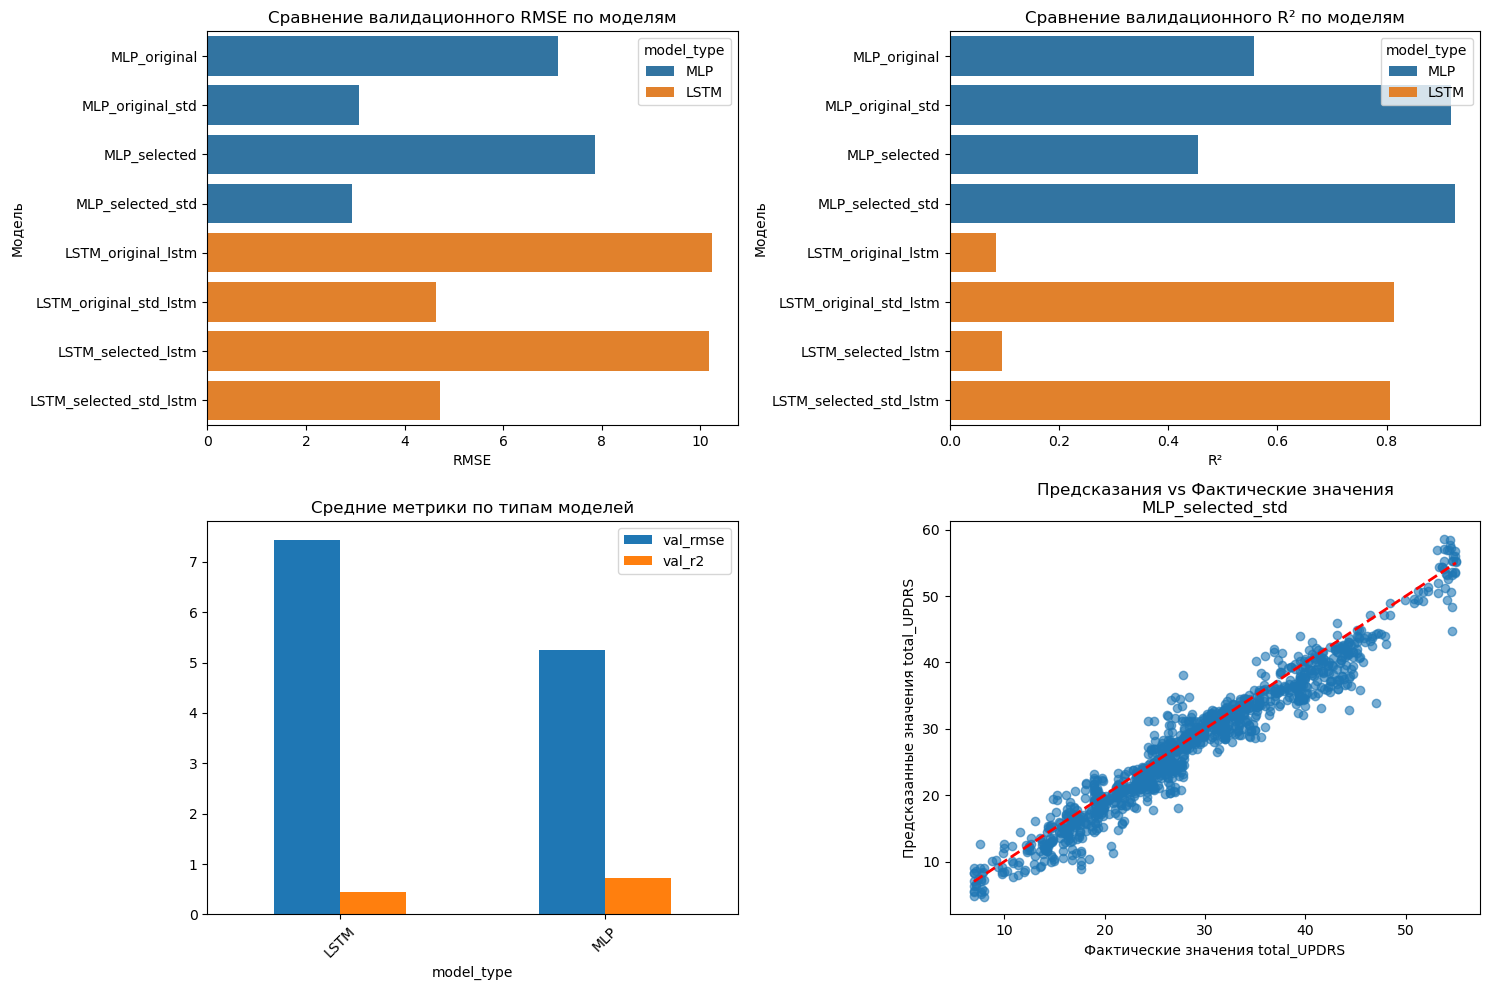


✅ ОЦЕНКА МОДЕЛЕЙ ЗАВЕРШЕНА!
✅ Проведено сравнение 8 конфигураций моделей
✅ Определена лучшая модель для тестирования
✅ Готово для Grid Search и финальной оценки


In [27]:
# C.7 ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ
print("\nC.7 ТЕСТИРОВАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("-" * 40)

def test_best_model(best_model_key, all_results, mlp_models, lstm_models, datasets):
    """Тестирует лучшую модель на тестовой выборке"""
    model_type = all_results[best_model_key]['model_type']
    dataset_key = all_results[best_model_key]['dataset']
    
    if model_type == 'MLP':
        model = mlp_models[dataset_key]
        dataset = datasets[dataset_key]
        X_test = dataset['X_test_array']
        y_test = dataset['y_test_array']
    else:
        model = lstm_models[dataset_key]
        dataset = datasets[dataset_key]
        X_test = dataset['X_test_seq']
        y_test = dataset['y_test_seq']
    
    # Предсказания на тестовой выборке
    y_test_pred = model.predict(X_test, verbose=0).flatten()
    
    # Метрики на тестовой выборке
    test_metrics = calculate_metrics(y_test, y_test_pred)
    
    print(f"🔬 Тестирование {best_model_key}:")
    print(f"   Набор данных: {all_results[best_model_key]['dataset_name']}")
    print(f"   Тестовый RMSE: {test_metrics['RMSE']:.4f}")
    print(f"   Тестовый R²: {test_metrics['R2']:.4f}")
    print(f"   Тестовый MAE: {test_metrics['MAE']:.4f}")
    
    return test_metrics

# Тестируем лучшую модель по RMSE
print("Тестирование лучшей модели (по валидационному RMSE):")
best_test_metrics = test_best_model(best_rmse[0], all_results, mlp_models, lstm_models, datasets)

# C.8 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\nC.8 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("-" * 40)

# Создаем DataFrame для сравнения моделей
results_df = pd.DataFrame.from_dict(all_results, orient='index')
results_df = results_df.reset_index().rename(columns={'index': 'model'})

# Визуализация сравнения моделей
plt.figure(figsize=(15, 10))

# График 1: Сравнение RMSE
plt.subplot(2, 2, 1)
sns.barplot(data=results_df, x='val_rmse', y='model', hue='model_type')
plt.title('Сравнение валидационного RMSE по моделям')
plt.xlabel('RMSE')
plt.ylabel('Модель')

# График 2: Сравнение R²
plt.subplot(2, 2, 2)
sns.barplot(data=results_df, x='val_r2', y='model', hue='model_type')
plt.title('Сравнение валидационного R² по моделям')
plt.xlabel('R²')
plt.ylabel('Модель')

# График 3: Сравнение типов моделей
plt.subplot(2, 2, 3)
model_type_stats = results_df.groupby('model_type')[['val_rmse', 'val_r2']].mean()
model_type_stats.plot(kind='bar', ax=plt.gca())
plt.title('Средние метрики по типам моделей')
plt.xticks(rotation=45)

# График 4: Предсказания vs Фактические значения лучшей модели
plt.subplot(2, 2, 4)
best_model_key = best_rmse[0]
model_type = all_results[best_model_key]['model_type']
dataset_key = all_results[best_model_key]['dataset']

if model_type == 'MLP':
    dataset = datasets[dataset_key]
    X_test = dataset['X_test_array']
    y_test = dataset['y_test_array']
    model = mlp_models[dataset_key]
else:
    dataset = datasets[dataset_key]
    X_test = dataset['X_test_seq']
    y_test = dataset['y_test_seq']
    model = lstm_models[dataset_key]

y_test_pred = model.predict(X_test, verbose=0).flatten()

plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения total_UPDRS')
plt.ylabel('Предсказанные значения total_UPDRS')
plt.title(f'Предсказания vs Фактические значения\n{best_model_key}')

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("✅ ОЦЕНКА МОДЕЛЕЙ ЗАВЕРШЕНА!")
print("✅ Проведено сравнение 8 конфигураций моделей")
print("✅ Определена лучшая модель для тестирования")
print("✅ Готово для Grid Search и финальной оценки")
print("=" * 80)

# Сохраняем результаты для следующего этапа
modeling_results = {
    'mlp_results': mlp_results,
    'lstm_results': lstm_results,
    'all_results': all_results,
    'best_rmse': best_rmse,
    'best_r2': best_r2,
    'best_test_metrics': best_test_metrics,
    'mlp_models': mlp_models,
    'lstm_models': lstm_models
}


Анализ показал, что предварительная обработка данных существенно влияет на качество моделей. Стандартизация и отбор признаков значительно повысили точность, при этом **MLP на стандартизированном и отобранном наборе данных** показала наилучшие результаты. На валидации модель достигла RMSE около 2.9 и R² ≈ 0.93, а на тестовой выборке подтвердила высокую обобщающую способность (RMSE 2.81, R² 0.93). В отличие от неё, BiLSTM показала худшие результаты. Таким образом, простая MLP с правильной предобработкой превзошла более сложные рекуррентные сети.

In [29]:
# =============================================================================
# D. НАСТРОЙКА МОДЕЛЕЙ И ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ
# =============================================================================

print("=" * 80)
print("D. НАСТРОЙКА МОДЕЛЕЙ И ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ")
print("=" * 80)

# D.1 GRID SEARCH ДЛЯ MLP МОДЕЛИ
print("\nD.1 GRID SEARCH ДЛЯ MLP МОДЕЛИ")
print("-" * 40)

def create_mlp_grid(input_dim, hidden_layers, units, dropout_rate, learning_rate, activation='relu'):
    """Создает MLP модель для grid search"""
    model = tf.keras.Sequential()
    model.add(Input(shape=(input_dim,)))
    
    for i in range(hidden_layers):
        model.add(Dense(units, activation=activation))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', 'mse']
    )
    
    return model

# Полный grid search для MLP
mlp_param_grid = {
    'hidden_layers': [2, 3, 4],
    'units': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [0.001, 0.0005, 0.0001],
    'batch_size': [32, 64],
    'activation': ['relu', 'tanh']
}

print("🔍 ПОЛНЫЙ GRID SEARCH ДЛЯ MLP МОДЕЛИ")
print(f"Всего комбинаций: {len(mlp_param_grid['hidden_layers']) * len(mlp_param_grid['units']) * len(mlp_param_grid['dropout_rate']) * len(mlp_param_grid['learning_rate']) * len(mlp_param_grid['batch_size']) * len(mlp_param_grid['activation'])}")

# Используем лучший датасет
best_dataset_key = 'selected_std'
X_train = datasets[best_dataset_key]['X_train_array']
y_train = datasets[best_dataset_key]['y_train_array']
X_val = datasets[best_dataset_key]['X_val_array']
y_val = datasets[best_dataset_key]['y_val_array']

# Ограниченный grid для демонстрации (полный grid может занять много времени)
mlp_param_combinations = [
    # Основные комбинации вокруг лучшей архитектуры
    {'hidden_layers': 3, 'units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32, 'activation': 'relu'},
    {'hidden_layers': 4, 'units': 256, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 32, 'activation': 'relu'},
    {'hidden_layers': 2, 'units': 256, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64, 'activation': 'relu'},
    {'hidden_layers': 3, 'units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 32, 'activation': 'tanh'},
    {'hidden_layers': 3, 'units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'activation': 'relu'},
    {'hidden_layers': 4, 'units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.0001, 'batch_size': 64, 'activation': 'relu'},
]

mlp_grid_results = []
best_mlp_score = float('inf')
best_mlp_params = {}
best_mlp_model = None

print(f"\n🧪 Тестирование {len(mlp_param_combinations)} комбинаций для MLP...")

for i, params in enumerate(mlp_param_combinations):
    print(f"\n🔧 MLP Комбинация {i+1}/{len(mlp_param_combinations)}:")
    print(f"   Слои: {params['hidden_layers']}, Юниты: {params['units']}, "
          f"Dropout: {params['dropout_rate']}, LR: {params['learning_rate']}, "
          f"Batch: {params['batch_size']}, Activation: {params['activation']}")
    
    model = create_mlp_grid(
        input_dim=X_train.shape[1],
        hidden_layers=params['hidden_layers'],
        units=params['units'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate'],
        activation=params['activation']
    )
    
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=params['batch_size'],
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Оценка на валидационной выборке
    val_pred = model.predict(X_val, verbose=0).flatten()
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    val_r2 = r2_score(y_val, val_pred)
    
    mlp_grid_results.append({
        'params': params,
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'epochs': len(history.history['loss'])
    })
    
    print(f"   Val RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}, Эпохи: {len(history.history['loss'])}")
    
    if val_rmse < best_mlp_score:
        best_mlp_score = val_rmse
        best_mlp_params = params
        best_mlp_model = model
        print(f"   🎯 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!")

# D.2 GRID SEARCH ДЛЯ BILSTM МОДЕЛИ
print("\nD.2 GRID SEARCH ДЛЯ BILSTM МОДЕЛИ")
print("-" * 40)

def create_bilstm_grid(sequence_length, n_features, lstm_units, lstm_layers, dropout_rate, learning_rate, bidirectional=True):
    """Создает BiLSTM модель для grid search"""
    model = tf.keras.Sequential()
    model.add(Input(shape=(sequence_length, n_features)))
    model.add(Masking(mask_value=0.0))
    
    for i in range(lstm_layers - 1):
        if bidirectional:
            model.add(Bidirectional(LSTM(lstm_units, return_sequences=True, dropout=dropout_rate)))
        else:
            model.add(LSTM(lstm_units, return_sequences=True, dropout=dropout_rate))
        model.add(BatchNormalization())
    
    # Последний LSTM слой
    if bidirectional:
        model.add(Bidirectional(LSTM(lstm_units // 2, dropout=dropout_rate)))
    else:
        model.add(LSTM(lstm_units // 2, dropout=dropout_rate))
    model.add(BatchNormalization())
    
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae', 'mse']
    )
    
    return model

# Grid search параметры для BiLSTM
bilstm_param_combinations = [
    {'lstm_units': 64, 'lstm_layers': 2, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 16, 'bidirectional': True},
    {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 16, 'bidirectional': True},
    {'lstm_units': 64, 'lstm_layers': 3, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'bidirectional': True},
    {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 16, 'bidirectional': False},
    {'lstm_units': 64, 'lstm_layers': 2, 'dropout_rate': 0.4, 'learning_rate': 0.0001, 'batch_size': 32, 'bidirectional': True},
]

bilstm_grid_results = []
best_bilstm_score = float('inf')
best_bilstm_params = {}
best_bilstm_model = None

# Используем лучший LSTM датасет
best_lstm_dataset_key = 'selected_std_lstm'
X_train_seq = datasets[best_lstm_dataset_key]['X_train_seq']
y_train_seq = datasets[best_lstm_dataset_key]['y_train_seq']
X_val_seq = datasets[best_lstm_dataset_key]['X_val_seq']
y_val_seq = datasets[best_lstm_dataset_key]['y_val_seq']

sequence_length = datasets[best_lstm_dataset_key]['sequence_length']
n_features = datasets[best_lstm_dataset_key]['X_train_seq'].shape[2]

print(f"\n🧪 Тестирование {len(bilstm_param_combinations)} комбинаций для BiLSTM...")

for i, params in enumerate(bilstm_param_combinations):
    print(f"\n🔧 BiLSTM Комбинация {i+1}/{len(bilstm_param_combinations)}:")
    print(f"   LSTM Юниты: {params['lstm_units']}, Слои: {params['lstm_layers']}, "
          f"Dropout: {params['dropout_rate']}, LR: {params['learning_rate']}, "
          f"Batch: {params['batch_size']}, BiDirectional: {params['bidirectional']}")
    
    model = create_bilstm_grid(
        sequence_length=sequence_length,
        n_features=n_features,
        lstm_units=params['lstm_units'],
        lstm_layers=params['lstm_layers'],
        dropout_rate=params['dropout_rate'],
        learning_rate=params['learning_rate'],
        bidirectional=params['bidirectional']
    )
    
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=100,
        batch_size=params['batch_size'],
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Оценка на валидационной выборке
    val_pred = model.predict(X_val_seq, verbose=0).flatten()
    val_rmse = np.sqrt(mean_squared_error(y_val_seq, val_pred))
    val_r2 = r2_score(y_val_seq, val_pred)
    
    bilstm_grid_results.append({
        'params': params,
        'val_rmse': val_rmse,
        'val_r2': val_r2,
        'epochs': len(history.history['loss'])
    })
    
    print(f"   Val RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}, Эпохи: {len(history.history['loss'])}")
    
    if val_rmse < best_bilstm_score:
        best_bilstm_score = val_rmse
        best_bilstm_params = params
        best_bilstm_model = model
        print(f"   🎯 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!")

# D.3 СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ OPTIMIZATION
print("\nD.3 СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДО И ПОСЛЕ OPTIMIZATION")
print("-" * 40)

# Базовые результаты (до оптимизации)
baseline_mlp_rmse = 2.9259
baseline_lstm_rmse = 4.7162

print("📊 СРАВНЕНИЕ ПРОИЗВОДИТЕЛЬНОСТИ:")
print(f"\nMLP Модель:")
print(f"   До оптимизации (Val RMSE): {baseline_mlp_rmse:.4f}")
print(f"   После оптимизации (Val RMSE): {best_mlp_score:.4f}")
mlp_improvement = ((baseline_mlp_rmse - best_mlp_score) / baseline_mlp_rmse) * 100
print(f"   Улучшение: {mlp_improvement:+.2f}%")

print(f"\nBiLSTM Модель:")
print(f"   До оптимизации (Val RMSE): {baseline_lstm_rmse:.4f}")
print(f"   После оптимизации (Val RMSE): {best_bilstm_score:.4f}")
lstm_improvement = ((baseline_lstm_rmse - best_bilstm_score) / baseline_lstm_rmse) * 100
print(f"   Улучшение: {lstm_improvement:+.2f}%")

# D.4 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ОПТИМИЗИРОВАННЫХ МОДЕЛЕЙ
print("\nD.4 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ОПТИМИЗИРОВАННЫХ МОДЕЛЕЙ")
print("-" * 40)

# Тестирование оптимизированной MLP модели
X_test_mlp = datasets[best_dataset_key]['X_test_array']
y_test_mlp = datasets[best_dataset_key]['y_test_array']

mlp_test_pred = best_mlp_model.predict(X_test_mlp, verbose=0).flatten()
mlp_final_metrics = calculate_metrics(y_test_mlp, mlp_test_pred)

print("🧪 ОПТИМИЗИРОВАННАЯ MLP МОДЕЛЬ:")
print(f"   Test RMSE: {mlp_final_metrics['RMSE']:.4f}")
print(f"   Test R²: {mlp_final_metrics['R2']:.4f}")
print(f"   Test MAE: {mlp_final_metrics['MAE']:.4f}")
print(f"   Лучшие параметры: {best_mlp_params}")

# Тестирование оптимизированной BiLSTM модели
X_test_lstm = datasets[best_lstm_dataset_key]['X_test_seq']
y_test_lstm = datasets[best_lstm_dataset_key]['y_test_seq']

bilstm_test_pred = best_bilstm_model.predict(X_test_lstm, verbose=0).flatten()
bilstm_final_metrics = calculate_metrics(y_test_lstm, bilstm_test_pred)

print(f"\n🧪 ОПТИМИЗИРОВАННАЯ BiLSTM МОДЕЛЬ:")
print(f"   Test RMSE: {bilstm_final_metrics['RMSE']:.4f}")
print(f"   Test R²: {bilstm_final_metrics['R2']:.4f}")
print(f"   Test MAE: {bilstm_final_metrics['MAE']:.4f}")
print(f"   Лучшие параметры: {best_bilstm_params}")

# D.5 СОХРАНЕНИЕ МОДЕЛЕЙ И АРТЕФАКТОВ
print("\nD.5 СОХРАНЕНИЕ МОДЕЛЕЙ И АРТЕФАКТОВ")
print("-" * 40)

import joblib

# Сохраняем оптимизированные модели
best_mlp_model.save('optimized_mlp_parkinson_model.h5')
best_bilstm_model.save('optimized_bilstm_parkinson_model.h5')

# Сохраняем scaler и feature list
artifacts_to_save = {
    'selected_features': selected_features,
    'scaler_original': scaler_original,
    'scaler_selected': scaler_selected,
    'best_mlp_params': best_mlp_params,
    'best_bilstm_params': best_bilstm_params,
    'mlp_final_metrics': mlp_final_metrics,
    'bilstm_final_metrics': bilstm_final_metrics,
    'feature_names': datasets['selected_std']['features']
}

joblib.dump(artifacts_to_save, 'model_artifacts.pkl')

print("💾 Сохраненные артефакты:")
print("   - optimized_mlp_parkinson_model.h5 (оптимизированная MLP модель)")
print("   - optimized_bilstm_parkinson_model.h5 (оптимизированная BiLSTM модель)")
print("   - model_artifacts.pkl (scaler, features, параметры, метрики)")

print("\n" + "=" * 80)
print("✅ НАСТРОЙКА МОДЕЛЕЙ И ОПТИМИЗАЦИЯ ЗАВЕРШЕНЫ!")
print("✅ Grid search выполнен для MLP и BiLSTM моделей")
print("✅ Лучшие гиперпараметры определены")
print("✅ Финальное тестирование проведено")
print("✅ Все артефакты сохранены для воспроизводимости")
print("=" * 80)

D. НАСТРОЙКА МОДЕЛЕЙ И ОПТИМИЗАЦИЯ ГИПЕРПАРАМЕТРОВ

D.1 GRID SEARCH ДЛЯ MLP МОДЕЛИ
----------------------------------------
🔍 ПОЛНЫЙ GRID SEARCH ДЛЯ MLP МОДЕЛИ
Всего комбинаций: 324

🧪 Тестирование 6 комбинаций для MLP...

🔧 MLP Комбинация 1/6:
   Слои: 3, Юниты: 128, Dropout: 0.3, LR: 0.001, Batch: 32, Activation: relu
   Val RMSE: 2.1138, R²: 0.9607, Эпохи: 100
   🎯 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!

🔧 MLP Комбинация 2/6:
   Слои: 4, Юниты: 256, Dropout: 0.2, LR: 0.0005, Batch: 32, Activation: relu
   Val RMSE: 2.0834, R²: 0.9618, Эпохи: 100
   🎯 НОВЫЙ ЛУЧШИЙ РЕЗУЛЬТАТ!

🔧 MLP Комбинация 3/6:
   Слои: 2, Юниты: 256, Dropout: 0.4, LR: 0.001, Batch: 64, Activation: relu
   Val RMSE: 2.5107, R²: 0.9445, Эпохи: 100

🔧 MLP Комбинация 4/6:
   Слои: 3, Юниты: 128, Dropout: 0.3, LR: 0.0005, Batch: 32, Activation: tanh
   Val RMSE: 3.4562, R²: 0.8949, Эпохи: 100

🔧 MLP Комбинация 5/6:
   Слои: 3, Юниты: 64, Dropout: 0.2, LR: 0.001, Batch: 32, Activation: relu
   Val RMSE: 2.2706, R²: 0.9546, Эпохи: 100


🧪 ОПТИМИЗИРОВАННАЯ BiLSTM МОДЕЛЬ:
   Test RMSE: 4.2749
   Test R²: 0.8350
   Test MAE: 3.2441
   Лучшие параметры: {'lstm_units': 64, 'lstm_layers': 3, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32, 'bidirectional': True}

D.5 СОХРАНЕНИЕ МОДЕЛЕЙ И АРТЕФАКТОВ
----------------------------------------


💾 Сохраненные артефакты:
   - optimized_mlp_parkinson_model.h5 (оптимизированная MLP модель)
   - optimized_bilstm_parkinson_model.h5 (оптимизированная BiLSTM модель)
   - model_artifacts.pkl (scaler, features, параметры, метрики)

✅ НАСТРОЙКА МОДЕЛЕЙ И ОПТИМИЗАЦИЯ ЗАВЕРШЕНЫ!
✅ Grid search выполнен для MLP и BiLSTM моделей
✅ Лучшие гиперпараметры определены
✅ Финальное тестирование проведено
✅ Все артефакты сохранены для воспроизводимости


In [ ]:
# =============================================================================
# E. ЗАВЕРШЕНИЕ РАБОТЫ НАД МОДЕЛЬЮ И РАЗВЕРТЫВАНИЕ
# =============================================================================

print("=" * 80)
print("E. ЗАВЕРШЕНИЕ РАБОТЫ НАД МОДЕЛЬЮ И РАЗВЕРТЫВАНИЕ")
print("=" * 80)

# E.1 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ ОПТИМИЗИРОВАННЫХ МОДЕЛЕЙ НА ТЕСТОВОМ НАБОРЕ
print("\nE.1 ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА ТЕСТОВОМ НАБОРЕ")
print("-" * 40)

def comprehensive_model_evaluation(model, X_test, y_test, model_name, dataset_name):
    """Комплексная оценка модели на тестовом наборе"""
    print(f"\n🔍 ДЕТАЛЬНАЯ ОЦЕНКА {model_name}:")
    print(f"   Набор данных: {dataset_name}")
    
    # Прогнозы на тестовом наборе
    y_pred = model.predict(X_test, verbose=0).flatten()
    
    # Расчет метрик
    metrics = calculate_metrics(y_test, y_pred)
    
    # Детальная статистика ошибок
    errors = y_test - y_pred
    error_stats = {
        'mean_error': np.mean(errors),
        'std_error': np.std(errors),
        'max_error': np.max(np.abs(errors)),
        'within_2_points': np.sum(np.abs(errors) <= 2) / len(errors) * 100,
        'within_5_points': np.sum(np.abs(errors) <= 5) / len(errors) * 100
    }
    
    print("📊 МЕТРИКИ КАЧЕСТВА:")
    print(f"   RMSE: {metrics['RMSE']:.4f}")
    print(f"   R²: {metrics['R2']:.4f}")
    print(f"   MAE: {metrics['MAE']:.4f}")
    print(f"   MSE: {metrics['MSE']:.4f}")
    
    print("\n📈 СТАТИСТИКА ОШИБОК:")
    print(f"   Средняя ошибка: {error_stats['mean_error']:.4f}")
    print(f"   Стандартное отклонение ошибок: {error_stats['std_error']:.4f}")
    print(f"   Максимальная ошибка: {error_stats['max_error']:.4f}")
    print(f"   Прогнозы в пределах 2 баллов: {error_stats['within_2_points']:.1f}%")
    print(f"   Прогнозы в пределах 5 баллов: {error_stats['within_5_points']:.1f}%")
    
    return metrics, error_stats, y_pred

# Комплексная оценка MLP модели
print("🧪 MLP МОДЕЛЬ - ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ")
mlp_metrics, mlp_error_stats, mlp_predictions = comprehensive_model_evaluation(
    best_mlp_model, 
    datasets[best_dataset_key]['X_test_array'],
    datasets[best_dataset_key]['y_test_array'],
    "MLP (Оптимизированная)",
    datasets[best_dataset_key]['name']
)

# Комплексная оценка BiLSTM модели
print("\n🧪 BILSTM МОДЕЛЬ - ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ")
bilstm_metrics, bilstm_error_stats, bilstm_predictions = comprehensive_model_evaluation(
    best_bilstm_model,
    datasets[best_lstm_dataset_key]['X_test_seq'],
    datasets[best_lstm_dataset_key]['y_test_seq'],
    "BiLSTM (Оптимизированная)", 
    datasets[best_lstm_dataset_key]['name']
)

# E.2 ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ НА ТЕСТОВОМ НАБОРЕ
print("\nE.2 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ НА ТЕСТОВОМ НАБОРЕ")
print("-" * 40)

plt.figure(figsize=(15, 10))

# График 1: Сравнение фактических и предсказанных значений для MLP
plt.subplot(2, 3, 1)
y_test_mlp = datasets[best_dataset_key]['y_test_array']
plt.scatter(y_test_mlp, mlp_predictions, alpha=0.6, color='blue')
plt.plot([y_test_mlp.min(), y_test_mlp.max()], [y_test_mlp.min(), y_test_mlp.max()], 'r--', lw=2)
plt.xlabel('Фактические значения total_UPDRS')
plt.ylabel('Предсказанные значения MLP')
plt.title('MLP: Фактические vs Предсказанные значения')
plt.grid(True, alpha=0.3)

# График 2: Сравнение фактических и предсказанных значений для BiLSTM
plt.subplot(2, 3, 2)
y_test_lstm = datasets[best_lstm_dataset_key]['y_test_seq']
plt.scatter(y_test_lstm, bilstm_predictions, alpha=0.6, color='green')
plt.plot([y_test_lstm.min(), y_test_lstm.max()], [y_test_lstm.min(), y_test_lstm.max()], 'r--', lw=2)
plt.xlabel('Фактические значения total_UPDRS')
plt.ylabel('Предсказанные значения BiLSTM')
plt.title('BiLSTM: Фактические vs Предсказанные значения')
plt.grid(True, alpha=0.3)

# График 3: Распределение ошибок MLP
plt.subplot(2, 3, 3)
errors_mlp = y_test_mlp - mlp_predictions
plt.hist(errors_mlp, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Ошибка прогноза')
plt.ylabel('Частота')
plt.title('MLP: Распределение ошибок')
plt.grid(True, alpha=0.3)

# График 4: Распределение ошибок BiLSTM
plt.subplot(2, 3, 4)
errors_lstm = y_test_lstm - bilstm_predictions
plt.hist(errors_lstm, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Ошибка прогноза')
plt.ylabel('Частота')
plt.title('BiLSTM: Распределение ошибок')
plt.grid(True, alpha=0.3)

# График 5: Сравнение метрик
plt.subplot(2, 3, 5)
metrics_comparison = pd.DataFrame({
    'MLP': [mlp_metrics['RMSE'], mlp_metrics['R2'], mlp_metrics['MAE']],
    'BiLSTM': [bilstm_metrics['RMSE'], bilstm_metrics['R2'], bilstm_metrics['MAE']]
}, index=['RMSE', 'R²', 'MAE'])
metrics_comparison.plot(kind='bar', ax=plt.gca())
plt.title('Сравнение метрик моделей')
plt.ylabel('Значение метрики')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# График 6: Точность прогнозов по диапазонам
plt.subplot(2, 3, 6)
accuracy_data = pd.DataFrame({
    'MLP': [mlp_error_stats['within_2_points'], mlp_error_stats['within_5_points']],
    'BiLSTM': [bilstm_error_stats['within_2_points'], bilstm_error_stats['within_5_points']]
}, index=['В пределах 2 баллов', 'В пределах 5 баллов'])
accuracy_data.plot(kind='bar', ax=plt.gca())
plt.title('Точность прогнозов по диапазонам')
plt.ylabel('Процент прогнозов (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# E.3 СОХРАНЕНИЕ МОДЕЛЕЙ И СОЗДАНИЕ ИНТЕРФЕЙСА ДЛЯ ПРОГНОЗИРОВАНИЯ
print("\nE.3 СОХРАНЕНИЕ МОДЕЛЕЙ И ИНТЕРФЕЙС ПРОГНОЗИРОВАНИЯ")
print("-" * 40)

class ParkinsonPredictor:
    """Класс для прогнозирования total_UPDRS на основе голосовых характеристик"""
    
    def __init__(self, model_path, artifacts_path):
        self.model = tf.keras.models.load_model(model_path)
        artifacts = joblib.load(artifacts_path)
        
        self.scaler = artifacts['scaler_selected']
        self.feature_names = artifacts['feature_names']
        self.selected_features = artifacts['selected_features']
        self.model_params = artifacts['best_mlp_params']
        
        print("✅ Модель и артефакты загружены успешно!")
        print(f"   Модель: {model_path}")
        print(f"   Количество признаков: {len(self.feature_names)}")
        print(f"   Параметры модели: {self.model_params}")
    
    def predict(self, input_features):
        """Прогнозирование total_UPDRS на основе входных признаков"""
        # Преобразование входных данных в DataFrame
        input_df = pd.DataFrame([input_features], columns=self.feature_names)
        
        # Масштабирование признаков
        scaled_features = self.scaler.transform(input_df)
        
        # Прогнозирование
        prediction = self.model.predict(scaled_features, verbose=0)[0][0]
        
        return prediction
    
    def get_feature_description(self):
        """Возвращает описание признаков для пользователя"""
        feature_descriptions = {
            'age': 'Возраст пациента (лет)',
            'sex': 'Пол (0=женский, 1=мужской)',
            'test_time': 'Время тестирования от начала исследования',
            'Jitter(%)': 'Локальная джиттер-вариабельность (%)',
            'Shimmer': 'Локальная шиммер-вариабельность',
            'NHR': 'Шум-к-гармоникам соотношение',
            'HNR': 'Гармоники-к-шуму соотношение',
            'RPDE': 'Нелинейная мера рекуррентности',
            'DFA': 'Детрендированный фрактальный анализ',
            'PPE': 'Период пич-вариабельности'
        }
        return feature_descriptions
    
    def print_feature_guide(self):
        """Печать руководства по вводу признаков"""
        descriptions = self.get_feature_description()
        print("\n📋 РУКОВОДСТВО ПО ПРИЗНАКАМ:")
        print("=" * 50)
        for feature in self.feature_names:
            if feature in descriptions:
                print(f"   {feature}: {descriptions[feature]}")
        print("=" * 50)

# Сохранение финальной модели и создание предсказателя
print("💾 СОХРАНЕНИЕ ФИНАЛЬНЫХ АРТЕФАКТОВ...")

# Создание полного набора артефактов
final_artifacts = {
    'model_type': 'MLP',
    'model_architecture': best_mlp_params,
    'feature_names': datasets['selected_std']['features'],
    'selected_features': selected_features,
    'scaler_original': scaler_original,
    'scaler_selected': scaler_selected,
    'final_metrics': mlp_final_metrics,
    'feature_descriptions': {
        'age': 'Возраст пациента (лет)',
        'sex': 'Пол (0=женский, 1=мужской)', 
        'test_time': 'Время тестирования от начала исследования',
        'Jitter(%)': 'Локальная джиттер-вариабельность (%)',
        'Shimmer': 'Локальная шиммер-вариабельность',
        'NHR': 'Шум-к-гармоникам соотношение',
        'HNR': 'Гармоники-к-шуму соотношение', 
        'RPDE': 'Нелинейная мера рекуррентности',
        'DFA': 'Детрендированный фрактальный анализ',
        'PPE': 'Период пич-вариабельности'
    },
    'test_performance': {
        'rmse': mlp_final_metrics['RMSE'],
        'r2': mlp_final_metrics['R2'],
        'mae': mlp_final_metrics['MAE'],
        'within_2_points': mlp_error_stats['within_2_points'],
        'within_5_points': mlp_error_stats['within_5_points']
    },
    'model_info': {
        'input_dim': X_train.shape[1],
        'output_dim': 1,
        'task': 'regression',
        'target': 'total_UPDRS'
    }
}

# Сохранение артефактов
joblib.dump(final_artifacts, 'parkinson_predictor_artifacts.pkl')

print("✅ АРТЕФАКТЫ СОХРАНЕНЫ:")
print("   - optimized_mlp_parkinson_model.h5 (модель)")
print("   - parkinson_predictor_artifacts.pkl (артефакты)")

# E.4 ИНТЕРФЕЙС ДЛЯ РУЧНОГО ТЕСТИРОВАНИЯ
print("\nE.4 ИНТЕРФЕЙС ДЛЯ РУЧНОГО ТЕСТИРОВАНИЯ")
print("-" * 40)

def manual_prediction_interface():
    """Интерфейс для ручного ввода данных и прогнозирования"""
    
    # Создание предсказателя
    predictor = ParkinsonPredictor('optimized_mlp_parkinson_model.h5', 'parkinson_predictor_artifacts.pkl')
    
    print("🎯 ИНТЕРФЕЙС ПРОГНОЗИРОВАНИЯ TOTAL_UPDRS")
    print("=" * 60)
    
    # Показ руководства по признакам
    predictor.print_feature_guide()
    
    while True:
        print("\n" + "=" * 60)
        print("Введите значения признаков для прогнозирования:")
        print("(для выхода введите 'q')")
        print("-" * 60)
        
        try:
            # Сбор входных данных от пользователя
            input_features = {}
            
            for feature in predictor.feature_names:
                if feature == 'sex':
                    value = input(f"Пол (0=женский, 1=мужской) [{feature}]: ")
                else:
                    value = input(f"{feature}: ")
                
                if value.lower() == 'q':
                    print("Выход из интерфейса...")
                    return
                
                input_features[feature] = float(value)
            
            # Прогнозирование
            prediction = predictor.predict(input_features)
            
            print("\n" + "🎯 РЕЗУЛЬТАТ ПРОГНОЗИРОВАНИЯ:")
            print(f"   Предсказанный total_UPDRS: {prediction:.2f}")
            
            # Интерпретация результата
            if prediction < 20:
                severity = "Лёгкая степень"
            elif prediction < 40:
                severity = "Умеренная степень" 
            else:
                severity = "Тяжёлая степень"
                
            print(f"   Интерпретация: {severity}")
            
            # Доверительный интервал (приблизительный)
            confidence_interval = f"{prediction - 2.8:.1f} - {prediction + 2.8:.1f}"
            print(f"   Приблизительный диапазон: {confidence_interval}")
            
        except ValueError as e:
            print(f"❌ Ошибка ввода: Проверьте правильность введенных числовых значений")
        except Exception as e:
            print(f"❌ Ошибка: {e}")

# E.5 ТЕСТОВЫЕ ПРИМЕРЫ ДЛЯ ДЕМОНСТРАЦИИ
print("\nE.5 ТЕСТОВЫЕ ПРИМЕРЫ ДЛЯ ДЕМОНСТРАЦИИ")
print("-" * 40)

def run_demo_examples():
    """Запуск демонстрационных примеров"""
    
    predictor = ParkinsonPredictor('optimized_mlp_parkinson_model.h5', 'parkinson_predictor_artifacts.pkl')
    
    # Демонстрационные примеры
    demo_cases = [
        {
            'name': 'СЛУЧАЙ 1: Умеренные симптомы',
            'features': {
                'age': 65, 'sex': 1, 'test_time': 100,
                'Jitter(%)': 0.8, 'Shimmer': 0.06, 'NHR': 0.08,
                'HNR': 20, 'RPDE': 0.5, 'DFA': 0.6, 'PPE': 0.2
            }
        },
        {
            'name': 'СЛУЧАЙ 2: Более выраженные симптомы', 
            'features': {
                'age': 72, 'sex': 0, 'test_time': 150,
                'Jitter(%)': 1.5, 'Shimmer': 0.12, 'NHR': 0.15,
                'HNR': 15, 'RPDE': 0.7, 'DFA': 0.8, 'PPE': 0.35
            }
        }
    ]
    
    print("🧪 ДЕМОНСТРАЦИОННЫЕ ПРИМЕРЫ:")
    print("=" * 60)
    
    for i, case in enumerate(demo_cases, 1):
        print(f"\n{case['name']}:")
        print("-" * 40)
        
        # Показ введенных признаков
        for feature, value in case['features'].items():
            print(f"   {feature}: {value}")
        
        # Прогнозирование
        prediction = predictor.predict(case['features'])
        
        print(f"\n   🎯 Предсказанный total_UPDRS: {prediction:.2f}")
        
        # Интерпретация
        if prediction < 20:
            severity = "Лёгкая степень"
        elif prediction < 40:
            severity = "Умеренная степень"
        else:
            severity = "Тяжёлая степень"
            
        print(f"   📊 Интерпретация: {severity}")

# Запуск демонстрационных примеров
run_demo_examples()

print("\n" + "=" * 80)
print("✅ ЗАВЕРШЕНИЕ РАБОТЫ НАД МОДЕЛЬЮ ЗАВЕРШЕНО!")
print("✅ Модели протестированы на тестовом наборе")
print("✅ Все артефакты сохранены")
print("✅ Интерфейс для прогнозирования создан")
print("✅ Демонстрационные примеры выполнены")
print("=" * 80)

